In [12]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
from scipy.ndimage import rotate # anti-clockwise
from PIL import Image # anti-clockwise


def process_unit_cell(result, ts, VA, VB, out_size):
    unit_cell = np.copy(result)
    polygon = Polygon([ts[::-1], (ts+VA)[::-1], (ts+VA+VB)[::-1], (ts+VB)[::-1]])
    for i in range(unit_cell.shape[0]):
        for j in range(unit_cell.shape[1]):
            if not polygon.contains(Point(j,i)):
                unit_cell[i,j] = 0
    return unit_cell

def rotate_xy(origin, point, angle):
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    The angle should be given in radians.
    """
    oy, ox = origin
    py, px = point
    
    theta = np.radians(angle)
    qx = ox + math.cos(theta) * (px - ox) - math.sin(theta) * (py - oy)
    qy = oy + math.sin(theta) * (px - ox) + math.cos(theta) * (py - oy)
    return int(qy), int(qx)

def blank_detection(region):
    return np.sum(region) == np.mean(region)

def remove_black_spot(img):
    region = np.copy(img).astype(np.int32)
    h, w = region.shape[:2]
    for k in range(region.shape[2]):
        if region[0,0,k] == 0:  region[0,0,k] = (region[1,0,k] + region[0,1,k])//2
        if region[h-1,0,k] == 0:  region[h-1,0,k] = (region[h-2,0,k] + region[h-1,1,k])//2
        if region[0,w-1,k] == 0:  region[0,w-1,k] = (region[0,w-2,k] + region[1,w-1,k])//2
        if region[h-1,w-1,k] == 0:  region[h-1,w-1,k] = (region[h-1,w-2,k] + region[h-2,w-1,k])//2

    for i in range(region.shape[0]):
        for j in range(region.shape[1]):
            for k in range(region.shape[2]):
                l = len(region[i-1:i+2, j-1:j+2, k].reshape(-1))
                avg = np.abs((np.sum(region[i-1:i+2, j-1:j+2, k])-region[i,j,k])/(l-1))
                if region[i,j,k] == 0:
                    region[i,j,k] = avg
    return region


# def process_unit_cell(unit_cell, output_shape, start_point):
#     unit_cell_in_image = np.zeros(output_shape, dtype=np.uint8)
#     unit_cell = unit_cell.astype(np.uint8)

#     unit_cell_in_image[start_point[0]:start_point[0]+unit_cell.shape[0], 
#                        start_point[1]:start_point[1]+unit_cell.shape[1]] += unit_cell
#     return unit_cell_in_image

def verify_image_vector(image, ts, va, vb): 

    ts = np.array(ts)[1], np.array(ts)[0]
    va = np.array(va)[1], np.array(va)[0]
    vb = np.array(vb)[1], np.array(vb)[0]

    plt.figure(figsize=(8,8))
    plt.imshow(image)
    
    plt.ylabel('Y-axis')
    plt.xlabel('X-axis')
    ax = plt.gca()
    
    array = np.array([[ts[0], ts[1], va[0], va[1]]])
    X, Y, U, V = zip(*array)
    ax.quiver(X, Y, U, V,color='b', angles='xy', scale_units='xy', scale=1, linewidth=0.3)
    
    array = np.array([[ts[0], ts[1], vb[0], vb[1]]])
    X, Y, U, V = zip(*array)
    ax.quiver(X, Y, U, V,color='b', angles='xy', scale_units='xy', scale=1, linewidth=0.3)

    plt.draw()
    plt.show()
    
def crop_area(source_image, shape, symmetry):
    
    in_size = source_image.shape
    area = int(round(np.random.normal(loc=960, scale=10))) # normal distribution near 960 in area
    if shape == 'square':
        angle = 90
        unit_h = int(round(np.sqrt(area)))
        unit_w = unit_h
        
        va = np.array((0, unit_w))
        vb = np.array((unit_h, 0))
        
    if shape == 'rectangular':
        angle = 90
        unit_w = int(round(np.random.normal(loc=31, scale=3)))
        unit_h = int(round(area/unit_w))
        
        va = np.array((0, unit_w))
        vb = np.array((unit_h, 0))
        
    if shape == 'oblique':
        
        angle = np.random.randint(45,85)
        unit_w = int(round(np.random.normal(loc=31, scale=3)))
        unit_h = int(round(area/unit_w))
        extra_w = int(round(np.abs(unit_h/np.tan(angle))))

        va = np.array((0, unit_w))
        # assume vb[0] is negative
        vb = np.array((unit_h, -extra_w))
        unit_w = unit_w + extra_w
        
        while 2 * np.abs(vb[1]) >= unit_w: # make sure oblique shape can be seperated to 3 parts
            angle = np.random.randint(45,85)

            unit_w = int(round(np.random.normal(loc=50, scale=3)))
            unit_h = int(round(area/unit_w))
            extra_w = int(round(np.abs(unit_h/np.tan(angle))))

            va = np.array((0, unit_w))
            # assume vb[0] is negative
            vb = np.array((unit_h, -extra_w))
            unit_w = unit_w + extra_w


    if shape == 'hexagonal':
        angle = 60
        area = area*2/3
        unit_h = int(np.sqrt(area/2*np.sqrt(3)))
        unit_w = int(round(3/2*unit_h*2/np.sqrt(3)))
        
        va = np.array((0, int(round(unit_w*2/3))))
        # assume vb[0] is negative
        vb = np.array((unit_h, -int(round(unit_h/np.tan(np.deg2rad(angle))))))
        
        
    if shape == 'rhombic':
        unit_w = int(round(np.random.normal(loc=31, scale=3)))
        unit_h = int(round(area/unit_w))
        # area of rhombic is half of the rectangular or oblique
        unit_h, unit_w = int(round(np.sqrt(2)*unit_h)), int(round(np.sqrt(2)*unit_w))
        
        # make sure even number for translation operation
        if unit_h % 2 == 1: unit_h += 1
        if unit_w % 2 == 1: unit_w += 1

        va = np.array((-int(round(unit_h/2)), int(round(unit_w/2))))
        vb = np.array((-va[0], va[1]))  
        
    if shape == 'triangle':
        area = area*2
        
        if symmetry in ['p4m', 'p4g']:
            unit_h = int(round(np.sqrt(area)))
            unit_w = unit_h
            
            va = np.array((-unit_h, unit_w))
            vb = np.array((0, unit_w))
            
        elif symmetry in ['p3']:
            angle = 60
            unit_w = int(np.sqrt(area/2*np.sqrt(3)))
            unit_h = int(round(3/2*unit_w*2/np.sqrt(3)))
            
            while unit_h % 3 != 0: unit_h+=1

            va = np.array((int(1/3*unit_h), unit_w))
            vb = np.array((int(2/3*unit_h), 0))
            
        elif symmetry in ['p3m1']:            
            # vertical triangle as primitive unit cell
            unit_w = int(np.sqrt(area * 2 // np.sqrt(3))) 
            while unit_w % 6 != 0: unit_w+=1
            unit_h = int(unit_w * np.sqrt(3) // 2)

            # horizontal triangles and vectors - reversed w,h position
            va = np.array((-int(1/2*unit_w), unit_h))
            vb = np.array((int(1/2*unit_w), unit_h))   
            
        elif symmetry in ['p31m', 'p6']:            
            unit_h = int(np.sqrt(area * 2 / np.sqrt(3))//2) 
            unit_w = int(round(unit_h * 2 * np.sqrt(3)))

            # horizontal triangles and vectors
            va = np.array((-unit_h, int(round(unit_w/2))))
            vb = np.array((0, unit_w))  
            
            
        elif symmetry in ['p6m']:            
            unit_h = int(np.sqrt(area / np.sqrt(3))) 
            unit_w = int(round(unit_h * np.sqrt(3)))
            while unit_w % 4 != 0: 
                unit_w+=1
                unit_h = int(round(unit_w / np.sqrt(3)))

            # horizontal triangles and vectors
            va = np.array((-unit_h, unit_w))
            vb = np.array((0, unit_w)) 
            
        else:
            unit_w = int(round(np.random.normal(loc=44, scale=3)))
            unit_h = int(round(area/unit_w))
            # area of rhombic is half of the rectangular or oblique
            unit_h, unit_w = int(round(np.sqrt(2)*unit_h)), int(round(np.sqrt(2)*unit_w))
        
            if (symmetry in ['p2']) and (unit_w % 2 == 1): unit_w+=1
        
            va = np.array((-unit_h, int(round(unit_w/2))))
            vb = np.array((0, unit_w))

            if symmetry in ['cmm']:
                va = np.array((-unit_h, unit_w))
                vb = np.array((0, unit_w))
                

    
    if 0>=(in_size[0]-unit_h) or 0>=(in_size[1]-unit_w):
        print(symmetry, shape, in_size, unit_h, unit_w)
        print(0, in_size[0]-unit_h, 0, in_size[1]-unit_w)
        source_start =  np.array((0,0)) 
        translate_start = np.array(( np.random.randint(0, unit_h), np.random.randint(0, unit_w) ))
        crop_region = np.zeros((unit_h, unit_w)).astype(np.uint8)

    else:
        source_start = np.array(( np.random.randint(0, in_size[0]-unit_h), np.random.randint(0, in_size[1]-unit_w)) ) # crop starting point
        translate_start = np.array(( np.random.randint(0, unit_h), np.random.randint(0, unit_w) ))
        crop_region = vector_crop(source_image, source_start, unit_h, unit_w)
        # print(crop_region.dtype)

    return crop_region, source_start, translate_start, va, vb



def vector_crop(source_image, ss, unit_h, unit_w):

    # convert to x, y coordinates from h, w
    ss_ = np.array((ss[1], ss[0]))
    a_ = np.array((ss[1], ss[0] + unit_h))
    b_ = np.array((ss[1] + unit_w, ss[0]))
    c_ = np.array((ss[1] + unit_w, ss[0] + unit_h))

    mask = np.zeros(source_image.shape, dtype=np.uint8)
    roi_corners = np.array([[ss_, a_, c_, b_]], dtype=np.int32)

    # compromise for triangle
    if unit_h < 0 and unit_w == 0:
        ss_ = ss_ + np.array((0,-1))
        roi_corners = np.array([[ss_, a_, b_]], dtype=np.int32)
    
    # fill the ROI so it doesn't get wiped out when the mask is applied
    channel_count = source_image.shape[2]  # i.e. 3 or 4 depending on your image
    ignore_mask_color = (255,)*channel_count
    cv2.fillPoly(mask, roi_corners, ignore_mask_color)
    # from Masterfool: use cv2.fillConvexPoly if you know it's convex
    
    masked_image = cv2.bitwise_and(source_image, mask)
    
    # crop rectangular region with x, y coordinates
    x_max, x_min = np.max((ss_[0], a_[0], b_[0], c_[0])), np.min((ss_[0], a_[0], b_[0], c_[0]))
    y_max, y_min = np.max((ss_[1], a_[1], b_[1], c_[1])), np.min((ss_[1], a_[1], b_[1], c_[1]))
    
    # compromise for triangle
    if unit_h and unit_w == 0:
        x_max, x_min = np.max((ss_[0], a_[0], b_[0])), np.min((ss_[0], a_[0], b_[0]))
        y_max, y_min = np.max((ss_[1], a_[1], b_[1])), np.min((ss_[1], a_[1], b_[1]))
    
    return np.roll(masked_image[y_min:y_max, x_min:x_max], np.abs(unit_h), axis=0)




def set_parameters(symmetry, shape, ts, va, vb):
    
    if symmetry =='p1':
        VA, VB = va, vb
        VA_, VB_ = va, vb
        
    if symmetry =='p2' :
        if shape == 'triangle':
            VA, VB = va, va*np.array((-1,1))
            VA_, VB_ = VA+VB, VB*np.array((2,0))
        else:
            VA, VB = va, 2*vb
            VA_, VB_ = VA, VB

    if symmetry in ['pm', 'pg']:
        VA, VB = va, 2*vb
        VA_, VB_ = va, 2*vb
        
    if symmetry in ['cm', 'pmm', 'pmg', 'pgg', 'p4']:
        VA, VB = 2*va, 2*vb
        VA_, VB_ = 2*va, 2*vb

    if symmetry == 'cmm':
        VA, VB = va, va*np.array((-1,1))
        VA_, VB_ = VA+VB, VB*np.array((2,0))

    if symmetry == 'p4m':
        VA, VB = va+va*np.array((-1,1)), va*np.array((-1,1))*np.array((2,0))
        VA_, VB_ = VA, VB

    if symmetry == 'p4g':
        ts = ts + vb
        VA, VB = va+va*np.array((-1,1)), va*np.array((-1,1))*np.array((2,0))
        VA_, VB_ = VA, VB
        
    if symmetry == 'p3':
        VA, VB = va*np.array((0,2)), va*np.array((3,-1))
        VA_, VB_ = VA, VB

    if symmetry == 'p3m1':
        VA, VB = (va*np.array((0,2))).astype(np.int32), vb*np.array((3,-1))
        VA_, VB_ = VA, VB
    
    if symmetry in ['p31m', 'p6']:
        vb_ = np.copy(vb)
        VA, VB = np.copy(vb), va*np.array((-3, -1))
        VA_, VB_ = VA, VB
        
    if symmetry in ['p6m']:
        vb_ = np.copy(vb)
        VA, VB = vb*2, va*np.array((-3, -1))
        VA_, VB_ = VA, VB

    return [ts, va, vb, VA, VB, VA_, VB_, shape]




def vector_translate(rec_crop, output_size, start_point, VA, VB):
    
    if VA[0] < 0:
        VA = VA + VB
        VB = (2*VB[0], 0)
    
    crop_h, crop_w = rec_crop.shape[:2]
    image = np.zeros((output_size[0]+VB[0]*4, output_size[1]+(VA[1])*4, output_size[2])).astype(np.uint8)
    
    roll = np.copy(image)
    roll[start_point[0]:rec_crop.shape[0]+start_point[0], start_point[1]:rec_crop.shape[1]+start_point[1]] = rec_crop
    compensate_times = 0
    
    for i in range(int(np.floor(image.shape[0]/VB[0]))):
        left_side = np.abs(VB[1]*i) - VA[1]*compensate_times
        while left_side > VA[1]:
            roll = np.roll(roll, shift=VA[1], axis=1)
            left_side -= VA[1]
            compensate_times += 1
        
        for j in range(int(np.floor(image.shape[1]/VA[1]))):
            image += np.roll(np.roll(roll, shift=(VA[1])*j+VB[1]*i, axis=1), shift=VB[0]*i, axis=0) 

    start_x = VA[1] + VB[1]
    while start_x < start_point[1]:
        start_x += VA[1]
    return image[VB[0]:VB[0]+output_size[0], start_x:start_x+output_size[1]]


def center_ts(ts, VA, VB, out_size, shape, symmetry, show_step=False):
    
    # move the translation start point close to center
    if show_step: print('before move', ts, VA, VB, shape)

    if shape in ['rectangular', 'square'] or symmetry in ['p4m', 'p4g']:
        while out_size[1]//2 - ts[1] > VA[1]:
            ts += VA
        while out_size[0]//2 - ts[0] > VB[0]:
            ts += VB

    elif shape in ['oblique', 'hexagonal'] or symmetry in ['p3', 'p3m1', 'p31m', 'p6', 'p6m']:
        while out_size[0]//2 - ts[0] > VB[0]:
            ts += VB
        while out_size[1]//2 - ts[1] > VA[1]:
            ts += VA

    elif shape in ['triangle']:
        while out_size[0]//2 - ts[0] > VB[0]:
            ts -= VA
        while out_size[1]//2 - ts[1] > VA[1]:
            ts += VB 
        while ts[1] - out_size[1]//2 > VA[1]:
            ts -= VB 

    elif shape in ['rhombic']:
        while out_size[0]//2 - ts[0] > VB[0]:
            ts = ts - VA + VB
        while out_size[1]//2 - ts[1] > VA[1]:
            ts = ts + VA + VB      

    if show_step: print('after move', ts, VA, VB)
    return ts
                


def re_center_ts(ts, VA, VB, out_size, show_step=False):
    
#     move start point inside the image
    if show_step:
        print('outsize:', out_size)
        print('initial start point:', ts)
        print('initial VA VB:', VA, VB)
    
    ts = np.array(ts)
    VA = np.array(VA)
    VB = np.array(VB)
    
    rep_times = 0
    new_dist, old_dist = 1, 0
    center = np.array(out_size)[:2]//3
    
    while rep_times < 4:
        rep_times = 0
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts+VA)[1] - center[1])**2 + ((ts+VA)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts += VA
            if show_step: print(ts, VA)
        else: rep_times += 1
            
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts-VA)[1] - center[1])**2 + ((ts-VA)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts -= VA
            if show_step: print(ts, -VA)
        else: rep_times += 1    
            
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts+VB)[1] - center[1])**2 + ((ts+VB)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts += VB
            if show_step: print(ts, VB)
        else: rep_times += 1       
            
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts-VB)[1] - center[1])**2 + ((ts-VB)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts -= VB
            if show_step: print(ts, -VB)
        else: rep_times += 1        

    if show_step: print('final start point:', ts)
    return ts
    
    
    
    
    
    
                
def rotate_xy(origin, point, angle):
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    The angle should be given in radians.
    """
    oy, ox = origin
    py, px = point
    
    theta = np.radians(-angle)
    qx = ox + math.cos(theta) * (px - ox) - math.sin(theta) * (py - oy)
    qy = oy + math.sin(theta) * (px - ox) + math.cos(theta) * (py - oy)
    return int(qy), int(qx)



def p1_unit(region, va, vb, show_step=False, shape='rectangular'):
    
    if shape in ['rectangular', 'square']:
        unit = np.copy(region)
    
    if shape in ['oblique', 'hexagonal']:
        p1 = np.copy(region)[:,:np.abs(vb[1])]
        p2 = np.copy(region)[:,np.abs(vb[1]):region.shape[1]-np.abs(vb[1])]
        p3 = np.copy(region)[:,-np.abs(vb[1]):]

        k = np.abs(vb[0]/vb[1])
        b = vb[0]
        for i in range(p1.shape[1]):
            for j in range(p1.shape[0]):
                if k*i + j < b:
                    p1[j,i] = p3[j,i]
        unit = np.concatenate((p2, p1), axis=1)
    
    if shape in ['rhombic']:
        unit = np.copy(region)
        # triangle primitive unit cell
        crop_region_roll = np.roll(np.roll(region, shift=region.shape[0]//2, axis=0), shift=region.shape[1]//2, axis=1)
        
        polygon = Polygon([(vb[0],0), (0,va[1]), (vb[0],2*va[1]), (2*vb[0],va[1])])
        for i in range(region.shape[1]):
            for j in range(region.shape[0]):
                if not polygon.contains(Point(j,i)):
                    unit[j,i] = crop_region_roll[j,i]
        unit = np.roll(unit, shift=vb[0], axis=0)
        
    if show_step:
        plt.imshow(unit)
        plt.show()
    
    return unit


# 180 degree rotation
def p2_unit(region, va, vb, show_step=False, shape='rectangular'):
    
    if shape in ['rectangular', 'square']:
        unit = np.vstack((region, np.rot90(region, 2)))       
    
    if shape in ['oblique', 'hexagonal']:
        p1 = np.copy(region)[:,:np.abs(vb[1])]
        p2 = np.copy(region)[:,np.abs(vb[1]):region.shape[1]-np.abs(vb[1])]
        p3 = np.copy(region)[:,-np.abs(vb[1]):]

        k = np.abs(vb[0]/vb[1])
        b = vb[0]
        for i in range(p1.shape[1]):
            for j in range(p1.shape[0]):
                if k*i + j < b:
                    p1[j,i] = p3[j,i]
        top_part = np.hstack((p1, p2))

        unit_ = np.vstack((top_part, np.rot90(top_part, 2)))
        unit = np.hstack((unit_, unit_))
        
        unit = unit[:, -vb[1]:-vb[1]+va[1]]
        
        if show_step:
            plt.imshow(unit)
            plt.show()
        
    
    if shape in ['triangle']:
        unit = np.vstack((region, np.rot90(region,2)))
        if show_step:
            plt.imshow(unit)
            plt.show()
        
        # triangle primitive unit cell
        unit_roll = np.roll(np.roll(unit, shift=unit.shape[0]//2, axis=0), shift=unit.shape[1]//2, axis=1)
        
        h, w = unit.shape[:2]
        polygon = Polygon([(h//2,0), (h,w//2), (h//2,w), [0,w//2]])
        for i in range(unit.shape[1]):
            for j in range(unit.shape[0]):
                if not polygon.contains(Point(j,i)):
                    unit[j,i] = unit_roll[j,i]
        unit = np.roll(unit, shift=h//2, axis=0)
        
    if show_step:
        print('unit shape:', unit.shape)
        plt.imshow(unit)
        plt.show()
    
    return unit


# mirror
def pm_unit(crop_region, show_step=False):
    # only rectangular and square are allowed
    unit = np.vstack((crop_region, cv2.flip(crop_region,0,dst=None))).astype(np.int32)
    return unit

# glide
def pg_unit(crop_region, show_step=False):
    # only rectangular and square are allowed
    unit = np.vstack((crop_region, cv2.flip(np.rot90(crop_region,2),0,dst=None))).astype(np.int32)
    return unit

# # 180 rotation
# def p2_unit(crop_region, show_step=False):
#     if vb[1] < 0: # oblique and hexagonal: pad extra space for 180 rotation
#         crop_region = np.hstack(( np.zeros([vb[0], np.abs(vb[1]), 3]), crop_region ))
#     # compromise for triangle
#     if va[0] < 0 and vb[0] == 0:
#         unit = np.vstack((np.rot90(crop_region, 2), np.roll(crop_region, -1, axis=1))).astype(np.int32)
#     else:
#         unit = np.vstack((np.roll(crop_region, -1, axis=1), np.rot90(crop_region, 2))).astype(np.int32)
#     return unit

# mirror + glide
def cm_unit(crop_region, show_step=False):
    # only rectangular and square are allowed
    unit = np.vstack((crop_region, cv2.flip(crop_region,0,dst=None))).astype(np.int32)
    unit = np.hstack((unit, np.roll(unit,shift=crop_region.shape[0],axis=0))).astype(np.int32)
    return unit

# 2 perpendicular directon mirror axises
def pmm_unit(crop_region, show_step=False):
    # only rectangular and square are allowed
    unit = np.vstack((crop_region, cv2.flip(crop_region,0,dst=None))).astype(np.int32)
    unit = np.hstack((unit, cv2.flip(unit,1,dst=None))).astype(np.int32)
    return unit

# mirror + 180 rotation
def pmg_unit(crop_region, show_step=False):
    # only rectangular and square are allowed
    unit = np.hstack((crop_region, np.rot90(crop_region,2))).astype(np.int32)
    unit = np.vstack((unit, cv2.flip(unit,0,dst=None))).astype(np.int32)
    return unit

# 180 rotation + glide
def pgg_unit(crop_region, show_step=False):
    # only rectangular and square are allowed
    unit = np.vstack((crop_region, np.rot90(crop_region,2))).astype(np.int32)
    unit = np.hstack((unit, np.roll(cv2.flip(unit,0,dst=None), shift=crop_region.shape[0], axis=0))).astype(np.int32)
    return unit

# 90 rotation
def p4_unit(crop_region, show_step=False):
    # only rectangular and square are allowed
    unit = np.hstack((crop_region, np.rot90(crop_region))).astype(np.int32)
    unit = np.vstack((unit, np.rot90(unit,2))).astype(np.int32)
    return unit

# 2 perpendicular directon mirror axises + 180 rotation (not on mirror axis)
def cmm_unit(crop_region, show_step=False):

    # triangle primitive unit cell
    crop_region_180 = np.rot90(crop_region, 2)
    
    k = crop_region.shape[0]/crop_region.shape[1]
    b = crop_region.shape[0]
    for i in range(crop_region.shape[1]):
        for j in range(crop_region.shape[0]):
            if k*i + j < b:
                crop_region[j,i] = crop_region_180[j,i]
    
    if show_step:
        plt.imshow(crop_region)
        plt.show()
        
    unit = np.vstack((crop_region, cv2.flip(crop_region,0,dst=None))).astype(np.int32)
    if show_step:
        plt.imshow(unit)
        plt.show()
        
    unit = np.hstack((cv2.flip(unit,1,dst=None), unit)).astype(np.int32)
    return unit


#  two rotation centres of order four (90°), 
# and reflections in four distinct directions (horizontal, vertical, and diagonals)
def p4m_unit(crop_region, show_step=False):

    # triangle primitive unit cell
    crop_region_flip = cv2.flip(np.rot90(crop_region, 1), 1, dst=None)
    
    b = crop_region.shape[0]
    for i in range(crop_region.shape[1]):
        for j in range(crop_region.shape[0]):
            if i + j < b:
                crop_region[j,i] = crop_region_flip[j,i]
    
    if show_step:
        plt.imshow(crop_region)
        plt.show()
        
    unit = np.vstack((cv2.flip(crop_region,0,dst=None), crop_region)).astype(np.int32)
    if show_step:
        plt.imshow(unit)
        plt.show()
    
    unit = np.hstack((unit, cv2.flip(unit,1,dst=None))).astype(np.int32)
    return unit

#  two rotation centres of order four (90°), 
# and reflections in four distinct directions (horizontal, vertical, and diagonals)

def p4g_unit(crop_region, show_step=False):

    # triangle primitive unit cell
    crop_region_45_flip = cv2.flip(np.rot90(crop_region, 1), 1, dst=None)
    
    k = crop_region.shape[0]/crop_region.shape[1]
    b = crop_region.shape[0]
    for i in range(crop_region.shape[1]):
        for j in range(crop_region.shape[0]):
            if k*i + j < b:
                crop_region[j,i] = crop_region_45_flip[j,i]
    
    if show_step:
        plt.imshow(crop_region)
        plt.show()
        
    unit = np.vstack((np.rot90(crop_region,1), crop_region)).astype(np.int32)
    if show_step:
        plt.imshow(unit)
        plt.show()
    
    unit = np.hstack((np.rot90(unit,2), unit)).astype(np.int32)
    return unit



def p3_unit(region, show_step=False):
    
    p2 = np.hstack((np.zeros(region.shape), region, np.zeros(region.shape))).astype(np.uint8)
    h, w = p2.shape[:2]

    p2_im = Image.fromarray(np.uint8(p2)) # have to transfer with uint8 type
    
    p1_im = p2_im.rotate(120, center=(w//3, h*2//3))
    p5_im = p2_im.rotate(-120, center=(w//3, h*2//3))
    
    p3_im = p2_im.rotate(120, center=(w*2//3, h//3))
    p4_im = p2_im.rotate(-120, center=(w*2//3, h//3))

    p1, p3 = np.array(p1_im), np.array(p3_im)
    p4, p5 = np.array(p4_im), np.array(p5_im)
    
    unit = np.copy(p2)
    polygon_p1 = Polygon([(-1,-1), (-1,w//3), (h*2//3,w//3), (h+1,-1)])
    for i in range(unit.shape[1]):
        for j in range(unit.shape[0]):
            if polygon_p1.contains(Point(j,i)):
                unit[j,i] = p1[j,i]  

    polygon_p3 = Polygon([(-1,w+1), (h//3,w*2//3-1), (h+1,w*2//3-1), (h+1,w+1)])
    for i in range(unit.shape[1]):
        for j in range(unit.shape[0]):
            if polygon_p3.contains(Point(j,i)):
                unit[j,i] = p3[j,i]
 
    polygon_p4 = Polygon([(-1,w//3), (h//3,w*2//3), (-1,w+1)])
    for i in range(unit.shape[1]):
        for j in range(unit.shape[0]):            
            if polygon_p4.contains(Point(j,i)):
                unit[j,i] = p4[j,i]
        
    polygon_p5 = Polygon([(h-1,-1), (h*2//3-1,w//3), (h+1,w*2//3)])
    for i in range(unit.shape[1]):
        for j in range(unit.shape[0]):            
            if polygon_p5.contains(Point(j,i)):
                unit[j,i] = p5[j,i]
        
    p1 = np.copy(unit)[:, :w//3]
    p2 = np.copy(unit)[:, w//3:2*w//3]
    p3 = np.copy(unit)[:, -w//3:]

    k = np.abs(h/(w//3))
    b = h
    for i in range(w):
        for j in range(h):
            if k*i + j < b:
                p1[j,i] = p3[j,i]
    unit = np.concatenate((p2, p1), axis=1)
    
    # approximation
    unit = remove_black_spot(unit)

    return unit


def p3m1_unit(region, show_step=False):    
    
    # construct the hexagonal region(pri-unit_cell in p3) first
        
    region_top = np.rot90(region, -1)
    region_bottom = cv2.flip(region, 1, dst=0)

        
    h, w = region_bottom.shape[:2]
    region_bottom_im = Image.fromarray(np.uint8(region_bottom)) # have to transfer with uint8 type
    region_bottom_im = region_bottom_im.rotate(-30, center=(w//2, h*2//3), expand=True)
    region_bottom = np.array(region_bottom_im)

    # crop the bottom w part in height
    region_bottom = region_bottom[-w:]
        
    while np.mean(region_bottom[:,0]) == np.sum(region_bottom[:,0]):
        region_bottom = region_bottom[:,1:]

    region_bottom = region_bottom[:,:h]

    h, w = region_top.shape[:2]
    region_top = np.concatenate((region_top, np.zeros((h//2, w, 3), dtype=np.int32)), 
                                axis=0) 
    
    region_bottom = np.concatenate((np.zeros((h//2, w, 3), dtype=np.int32), region_bottom), 
                                axis=0) 
        
    region = np.copy(region_top)
    polygon_top = Polygon([(h,0), (h//2,w), (int(h*3//2),w), (int(h*3//2),0)])
    for i in range(region_top.shape[1]):
        for j in range(region_top.shape[0]):
            if polygon_top.contains(Point(j,i)):
                region[j,i] = region_bottom[j,i]  
    
        
    unit = p3_unit(region, show_step)
    return unit


def p31m_unit(region, show_step=False):    
    # construct the hexagonal region(pri-unit_cell in p3) first
    region_flatten = np.concatenate((region, cv2.flip(region, 0, dst=0)))
    h, w = region_flatten.shape[:2]
    
    # rotate to right orientation
    region = rotate(region_flatten, angle = -60, reshape=True)
    h_f = int(round(1.5 * region_flatten.shape[0]))
    
    # crop 
    region = region[(region.shape[0]-h_f)//2: (region.shape[0]-h_f)//2 + h_f,
                    round(region.shape[1]/4):round(3*region.shape[1]/4)]

    # then follow the same step as p3
    unit = p3_unit(region, show_step)
    return unit

def p6_unit(region, show_step=False):    
    # construct the hexagonal region(pri-unit_cell in p3) first
    region_flatten = np.concatenate((region, np.rot90(region, 2)))
    h, w = region_flatten.shape[:2]
    
    region = rotate(region_flatten, angle = -60, reshape=True)
    h_f = int(round(1.5 * region_flatten.shape[0]))
    region = region[(region.shape[0]-h_f)//2: (region.shape[0]-h_f)//2 + h_f,
                    round(region.shape[1]/4):round(3*region.shape[1]/4)]

    # then follow the same step as p3
    unit = p3_unit(region, show_step)
    return unit

def p6m_unit(region, show_step=False):    
    # construct the hexagonal region(pri-unit_cell in p3) first
    region_top = np.concatenate((region, cv2.flip(region, 1, dst=0)), axis=1)
    region_flatten = np.concatenate((region_top, np.rot90(region_top, 2)))
    
    h, w = region_flatten.shape[:2]
    
    region = rotate(region_flatten, angle = -60, reshape=True)
    h_f = int(round(1.5 * region_flatten.shape[0]))
    region = region[(region.shape[0]-h_f)//2: (region.shape[0]-h_f)//2 + h_f,
                     :region_flatten.shape[1]]
    
    region = region[:, round(region.shape[1]/4):round(3*region.shape[1]/4)]
    
    if show_step:
        plt.imshow(region)
        plt.title('unit_region')
        plt.show()
    
    # then follow the same step as p3
    unit = p3_unit(region, show_step)
    return unit


def transformation(source_image, out_size, symmetry, shape='random', rotation=False, file=None, show_step=False):
    
    if show_step:
        plt.imshow(source_image)
        plt.title('source image')
        plt.show()
        
    if source_image.dtype == np.float32 or source_image.dtype == np.float64:
        source_image = (source_image*255).astype(np.uint8)
        
    if symmetry =='p1':
        shape_list = ['rectangular', 'square', 'rhombic', 'oblique', 'hexagonal']

    if symmetry =='p2' :
        shape_list = ['rectangular', 'square', 'triangle', 'oblique', 'hexagonal']

    if symmetry in ['pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg']:
        shape_list = ['rectangular', 'square']

    if symmetry == 'p4': 
        shape_list = ['square']

    if symmetry == 'cmm' or symmetry == 'p4m' or symmetry == 'p4g':
        shape_list = ['triangle']
        
    if symmetry in ['p3', 'p3m1', 'p31m', 'p6', 'p6m']:
        shape_list = ['triangle']
    
    if shape == 'random':
        shape = random.choice(shape_list)

    if shape not in shape_list: 
        raise ValueError(shape, 'is not allowed for ', symmetry, 'symmetry.')            
        
    
    # crop primitive unit cell

    ### crop rectangular region first
    region, ss, ts, va, vb = crop_area(source_image, shape, symmetry)

    ##  detect the blank region:
    attempt = 0
    while blank_detection(region):
        print(f'Attempt {attempt}: detected blank image')
        region, ss, ts, va, vb = crop_area(source_image, shape, symmetry)
        attempt+=1
        if attempt>5:
            raise ValueError(f'Cannot find a valid region to crop, source image maybe blank or has a incompatible shape: \n image size={source_image.shape}, shape of crop region={region.shape}, shape is {shape}, symmetry is {symmetry}, file is {file}')
        
    
    ### define all the parameters then
    [ts, va, vb, VA, VB, VA_, VB_, shape] = set_parameters(symmetry, shape, ts, va, vb)
    
    if show_step:
        plt.imshow(region)
        plt.title('primitive unit cell')
        plt.show()
    
    # construct translation unit cell
    if symmetry == 'p1':
        unit = p1_unit(region, va, vb, show_step, shape)
        
    if symmetry == 'p2':
        unit = p2_unit(region, va, vb, show_step, shape)
        
    if symmetry =='pm':
        unit = pm_unit(region, show_step)
    if symmetry =='pg':
        unit = pg_unit(region, show_step)
    if symmetry =='cm':
        unit = cm_unit(region, show_step)

    if symmetry =='pmm':
        unit = pmm_unit(region, show_step)
    if symmetry =='pmg':
        unit = pmg_unit(region, show_step)
    if symmetry =='pgg':
        unit = pgg_unit(region, show_step)
    if symmetry =='p4':
        unit = p4_unit(region, show_step)
        
    if symmetry == 'cmm':
        unit = cmm_unit(region, show_step)
    if symmetry == 'p4m':
        unit = p4m_unit(region, show_step)
    if symmetry == 'p4g':
        unit = p4g_unit(region, show_step)

    if symmetry == 'p3':
        unit = p3_unit(region, show_step)
    if symmetry == 'p3m1':
        unit = p3m1_unit(region, show_step)
    if symmetry == 'p31m':
        unit = p31m_unit(region, show_step)
    if symmetry == 'p6':
        unit = p6_unit(region, show_step)
    if symmetry == 'p6m':
        unit = p6m_unit(region, show_step)
        
    if show_step:
        print(unit.shape)
        plt.imshow(unit)
        plt.title('translation unit cell '+str(VA)+str(VB)+str(VA_)+str(VB_))
        plt.show()
        
    # temporarily fix the issue that VB_ is one pixel large than right value
    if symmetry == 'p6m':
        VB_[1] = -unit.shape[1]//2
    
    
    # translate the translation unit cell
    if not rotation:
        result = vector_translate(unit, out_size, ts, VA_, VB_)
#             ts = center_ts(ts, VA, VB, out_size, shape, symmetry, show_step=False)

        if show_step:
            plt.imshow(result)
            plt.show()    
            
    else:
        angle = np.random.randint(0,360)
        result = vector_translate(unit, (int(out_size[0]*1.42), int(out_size[0]*1.42), out_size[2]),
                                    ts, VA_, VB_)
        
#             ts = center_ts(ts, VA, VB, out_size, shape, symmetry, show_step=False)
        ts = re_center_ts(ts, VA, VB, out_size, show_step)
        
        if show_step:
            plt.imshow(result)
            plt.show()

        origin = int(out_size[0]*1.42//2), int(out_size[1]*1.42//2)

        if show_step: 
            print('before rotate, ts, va, vb, VA, VB, origin, angle', 
                    ts, va, vb, VA, VB, origin, angle)
        
            verify_image_vector(result, ts, va, vb)
            verify_image_vector(result, ts, VA, VB)
                    
        result = rotate(result, angle, reshape=False)
        result = result[int((out_size[0]*1.42-out_size[0])//2):int((out_size[0]*1.42-out_size[0])//2)+out_size[0],
                        int((out_size[1]*1.42-out_size[1])//2):int((out_size[1]*1.42-out_size[1])//2)+out_size[1]]
        
#             ts = ts[0]-int((out_size[0]*1.42-out_size[0])//2), ts[1]-int((out_size[1]*1.42-out_size[1])//2)
        ts = rotate_xy(origin, ts, angle)
        ts = ts[0]-int((out_size[0]*1.42-out_size[0])//2), ts[1]-int((out_size[1]*1.42-out_size[1])//2)
        
        va, vb = rotate_xy((0,0), va, angle), rotate_xy((0,0), vb, angle)
        VA, VB = rotate_xy((0,0), VA, angle), rotate_xy((0,0), VB, angle)
        
        if show_step:
            print('after rotate, ts, va, vb, VA, VB', ts, va, vb, 
                    VA, VB, origin, angle)
            verify_image_vector(result, ts, va, vb)
            verify_image_vector(result, ts, VA, VB)

    # finalize the metadata and center the starting point
    ts = re_center_ts(ts, VA, VB, out_size, show_step)
    
        
    shape_dict = { 'rectangular': 0, 'square': 0, 'oblique': 1, 'hexagonal': 1, 'rhombic': 2, 'triangle': 3 }
    shape_int = shape_dict[shape]

    symmetry_dict = {'p1': 0, 'p2': 1, 'pm': 2, 'pg': 3, 'cm': 4, 'pmm': 5, 'pmg': 6, 'pgg': 7, 'cmm': 8, 
                     'p4': 9, 'p4m': 10, 'p4g': 11, 'p3': 12, 'p3m1': 13, 'p31m': 14, 'p6': 15, 'p6m': 16}
    symmetry_int = symmetry_dict[symmetry]

    # v_angle = int(r
    # ound(np.degrees(np.arccos(np.dot(VA/np.linalg.norm(VA), 
                                                    # VB/np.linalg.norm(VB))))))
    metadata = np.array([ts, va, vb, VA, VB, (symmetry_int, shape_int)] )  
        
    if show_step:
        plt.imshow(result)
        plt.title('output image')
        plt.show()
            
#     process the unit cell and metadata
    unit_cell = process_unit_cell(result, ts, VA, VB, out_size)

    return result, unit_cell, metadata

In [13]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import math, random
from PIL.ImageDraw import Image, Draw
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.stats import truncnorm
from sympy import symbols, Eq, solve
import time
import cv2
from scipy.ndimage import rotate # anti-clockwise

from multiprocessing import Pool
import os, re, time, shutil


def re_center_ts(ts, VA, VB, out_size):
    
    ts = np.array(ts)
    VA = np.array(VA)
    VB = np.array(VB)
    
    rep_times = 0
    new_dist, old_dist = 1, 0
    center = np.array(out_size)[:2]//3
    
    while rep_times < 4:
        rep_times = 0
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts+VA)[1] - center[1])**2 + ((ts+VA)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts += VA
        else: rep_times += 1
            
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts-VA)[1] - center[1])**2 + ((ts-VA)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts -= VA
        else: rep_times += 1    
            
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts+VB)[1] - center[1])**2 + ((ts+VB)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts += VB
        else: rep_times += 1       
            
        old_dist = np.sqrt( (ts[1] - center[1])**2 + (ts[0] - center[0])**2 )
        new_dist = np.sqrt( ((ts-VB)[1] - center[1])**2 + ((ts-VB)[0] - center[0])**2 )
        if new_dist < old_dist: 
            ts -= VB
        else: rep_times += 1        

    return ts


def verify_image_vector(image, ts, va, vb): 
            
    ts = ts[1], ts[0]
    va = va[1], va[0]
    vb = vb[1], vb[0]

#     plt.figure(figsize=(8,8))
    plt.imshow(image)
    
    plt.ylabel('Y-axis')
    plt.xlabel('X-axis')
    ax = plt.gca()
    
    array = np.array([[ts[0], ts[1], va[0], va[1]]])
    X, Y, U, V = zip(*array)
    ax.quiver(X, Y, U, V,color='b', angles='xy', scale_units='xy', scale=1, linewidth=0.3)
    
    array = np.array([[ts[0], ts[1], vb[0], vb[1]]])
    X, Y, U, V = zip(*array)
    ax.quiver(X, Y, U, V,color='b', angles='xy', scale_units='xy', scale=1, linewidth=0.3)

    plt.draw()
    plt.show()


# basic functions:
import numpy as np

def draw_atom(image, coordinate, r, color='white', noise=False, out_dtype=np.float32):
    '''
    f(x) = a*(exp(-(x-mu)^2)/2*sigma^2), 
    a is the height of curve's peak, 
    mu is the position of the center of the peak,
    and sigma controls the width of the 'bell'.

    coordinate: (x, y)
    '''
    if image.dtype == np.uint8:
        image_d = np.copy(np.float32(image/255.))
    else:
        image_d = np.copy(image)

    h, w = image_d.shape[:2]
    x, y = round(coordinate[0]), round(coordinate[1])
    i, j = np.meshgrid(np.linspace(-1, 1, 2 * r), np.linspace(-1, 1, 2 * r))
    d = np.sqrt(i * i + j * j)
    sigma, mu = 0.40, 0.0
    g = np.exp(-( (d - mu) ** 2 / (2.0 * sigma ** 2)))

    color_dict = {'red': [1, 0, 0], 'green': [0, 1, 0], 'blue': [0, 0, 1], 'white': [1, 1, 1]}
    color_rgb = color_dict.get(color, [1, 1, 1])  # Default to white if color is not recognized

    g_rgb = g[:, :, np.newaxis] * np.array(color_rgb)
    g_rgb[g_rgb < 5e-2] = 0  # clean up the edges so overlapping of two atoms are not too obvious

    if noise:
        noise_matrix = np.random.random((2 * r, 2 * r, 3))
        g_rgb = g_rgb * noise_matrix

    if x + r > w or x - r < 0 or y + r > h or y - r < 0:
        atom_padded = np.zeros((np.max((y + r, h)) - np.min((y - r, 0)), np.max((x + r, w)) - np.min((x - r, 0)), 3))
        x_ = x - np.min((0, x - r))
        y_ = y - np.min((0, y - r))

        atom_padded[int(y_ - r): int(y_ + r), x_ - r:x_ + r, :] += g_rgb
            
        atom = np.copy(atom_padded[0 - np.min((0, y - r)):h - np.min((0, y - r)), 0 - np.min((0, x - r)):w - np.min((0, x - r)), :])

    else:
        atom = np.zeros((h, w, 3))
        atom[int(y - r): int(y + r), x - r:x + r, :] += g_rgb

    image_d += atom
    if out_dtype == np.uint8:
        return (image_d * 255).astype(np.uint8)
    else:
        return image_d




# def draw_atom(image, coordinate, r, color='white', noise=False): # making white dot, assuming black image background
#     '''
#     f(x) = a*(exp(-(x-mu)^2)/2*sigma^2), 
#     a is the height of curve's peak, 
#     mu is the position of the center of the peak,
#     and sigma controls the width of the 'bell'.
#     '''
#     image_d = np.copy(image)
    
#     h,w = image_d.shape[:2]
#     x, y = round(coordinate[0]), round(coordinate[1])
#     i, j = np.meshgrid(np.linspace(-1,1,2*r), np.linspace(-1,1,2*r))
#     d = np.sqrt(i*i+j*j)
#     sigma, mu = 0.38, 0.0
#     g = np.exp(-( (d-mu)**2 / ( 2.0 * sigma**2 ) ) )
#     g_rgb = np.dstack([g,g,g])
#     g_rgb[g_rgb<5e-2]=0 #clean up the edges so overlapping of two atoms are not too obvious

#     color_dict = {'red':0, 'green':1, 'blue':2}

#     if x+r>w or x-r<0 or y+r>h or y-r<0:
#         atom_padded = np.zeros((np.max((y+r,h))-np.min((y-r,0)), np.max((x+r,w))-np.min((x-r,0)), 3))
#         x_ = x - np.min((0,x-r))
#         y_ = y - np.min((0,y-r))

#         if color == 'white':
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, :] += g_rgb
            
#         elif color == 'c1':
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 0] += g
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 1] += g*0.8
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 2] += g*0.4
            
#         elif color == 'c2':
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 0] += g
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 1] += g*0.8
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 2] += g*0.4
            
#         else:
#             atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, color_dict[color]] += g
            
#         atom = np.copy(atom_padded[0-np.min((0,y-r)):h-np.min((0,y-r)), 0-np.min((0,x-r)):w-np.min((0,x-r)), :])

#     else:
#         atom = np.zeros((h,w,3))

#         if color == 'white':
#             atom[int(y-r): int(y+r), x-r:x+r, :] += g_rgb
            
#         elif color == 'c1':
#             atom[int(y-r): int(y+r), x-r:x+r, 0] += g
#             atom[int(y-r): int(y+r), x-r:x+r, 1] += g*0.8
#             atom[int(y-r): int(y+r), x-r:x+r, 2] += g*0.3
            
#         elif color == 'c2':
#             atom[int(y-r): int(y+r), x-r:x+r, 0] += g*0.5
#             atom[int(y-r): int(y+r), x-r:x+r, 1] += g*0.3
#             atom[int(y-r): int(y+r), x-r:x+r, 2] += g*0.8
            
#         else:
#             atom[int(y-r): int(y+r), x-r:x+r, color_dict[color]] += g
#     image_d += atom
#     return image_d


def normal_random(low, upp, num=1):
    mean = int((upp-low)/1.5)
    sd = int(1/4*(upp-low))
    return truncnorm(
        (low - mean) / sd, (upp - mean) / sd, loc=mean, scale=sd).rvs(num).astype(int)

def define_size(xa, ya, xb, yb, radius, shape, angle=None):
    x_lo_limit, y_lo_limit = np.abs(xb-xa)+radius, np.abs(yb-ya)+radius # large enough in case overlapping
    area = 8*radius**2 # by experience
    x_hi_limit = round(area/y_lo_limit)

    # default: rectangular, oblique
    unit_w = random.randint(np.min((x_lo_limit, x_hi_limit)), np.max((x_lo_limit, x_hi_limit)))
    unit_h = area/unit_w

    while np.max((unit_w, unit_h)) / np.min((unit_w, unit_h)) >1.5:
        unit_w = random.randint(np.min((x_lo_limit, x_hi_limit)), np.max((x_lo_limit, x_hi_limit)))
        unit_h = area/unit_w
    
    if shape == 'square':
        unit_w = math.sqrt(area)
        while unit_w < np.min((x_lo_limit, x_hi_limit)) and unit_w > np.max((x_lo_limit, x_hi_limit)):
            unit_w = random.randint(np.min((x_lo_limit, x_hi_limit)), np.max((x_lo_limit, x_hi_limit)))
        unit_h = area/unit_w
        
    if shape == 'hexagonal':
        unit_w = math.sqrt( area/math.sin(math.radians(60)) )
        unit_h = area/unit_w

    if shape == 'rhombic':
        (unit_h, unit_w) = (math.sqrt(2)*unit_h, math.sqrt(2)*unit_w) # maintain the same atom/area ratio

    if shape == 'triangle':
        (unit_h, unit_w) = (math.sqrt(2)*unit_h, math.sqrt(2)*unit_w) # maintain the same atom/area ratio
        unit_h, unit_w = np.sort((unit_w, unit_h)) # make sure unit_w is larger than unit_h: for better visualization
    
    if shape == 'triangle':
        unit_h = math.sqrt(area/math.tan( math.radians(angle/2) ) )
        unit_w = 2*area/unit_h

    if shape == 'triangle-right':
        unit_h = math.sqrt(2*area/math.tan(math.radians(angle)))
        unit_w = 2*area/unit_h
    return int(round(unit_w)), int(round(unit_h))

def two_point(img, radius, shape, gap=0): 
    h, w = img.shape[:2]
    
    x_low_limit, x_high_limit = 4*radius, w-4*radius
    y_low_limit, y_high_limit = 4*radius, h-4*radius

    if  x_low_limit > x_high_limit or y_low_limit > y_high_limit: 
        raise ValueError('Atom radius too large, no space for two atoms!')
    
    xa,ya,xb,yb=0,0,0,0
    vertices = [(radius,radius), (radius,h-radius), (w-radius,h-radius), (w-radius,radius)]
    poly = Polygon(vertices)
    while not poly.contains(Point(xa, ya) or not poly.contains(Point(xb, yb))):
        xa, ya = random.randint(x_low_limit, x_high_limit), random.randint(y_low_limit, y_high_limit)
        xb, yb = xa+2*radius+random.randint(0,int(gap*radius)), ya
    center = (int((xa+xb)/2), ya)  

    if shape in ['rectangular', 'square']:
        while (np.abs(xa-xb)<radius or np.abs(ya-yb)<radius): 
            angle_d = random.randint(0,359)
            xa, ya = rotate_xy(center, (xa, ya), angle_d)
            xb, yb = rotate_xy(center, (xb, yb), angle_d)

    if shape in ['oblique', 'hexagonal', 'rhombic', 'triangle', 'triangle-120', 
                 'triangle-right', 'triangle-right-45', 'triangle-right-60']:
        while np.abs(ya-yb)<radius: 
            angle_d = random.randint(0,359)
            xa, ya = rotate_xy(center, (xa, ya), angle_d)
            xb, yb = rotate_xy(center, (xb, yb), angle_d)

    return (xa, ya), (xb, yb)



def unit_cell(img, radius, shape, symmetry, boundary=False, avoid_break_symmetry=True):
    def point_to_line(p1, p2, p3):
        ''' calculate the distance from p3 perpendicular to p1,p2 line'''
        return np.linalg.norm(np.cross(p2-p1, p1-p3))/np.linalg.norm(p2-p1)   
    
    if shape == 'rectangular' or shape == 'square':
        
        radius_original = radius # radius_ is the orignal radius; radius is the one used for Polygon and draw_atom
        
        # define atom a,b positions and primitive unit cell size
        xa, ya, xb, yb, unit_w, unit_h = 0, 0, 0, 0, 0, 0
        if avoid_break_symmetry:
            lw = np.max((2, 0.2*unit_w))
            lh = np.max((2, 0.2*unit_h))
            
            while (np.abs(xa+unit_w/2-xb) < lw) and (np.abs(ya+unit_h/2-yb) < lh):
                
#             (xb,yb) == (round(xa+unit_w), round(ya+unit_h/2)): 
                (xa,ya), (xb,yb) = two_point(img, radius, shape)   
                unit_w, unit_h = define_size(xa, ya, xb, yb, radius, shape)

                # make sure point_a is closer to origin point, easier to visualize
                xa-=int(xa>xb)*unit_w
                ya-=int(ya>yb)*unit_h
                                
                
        # define angle and delta_x
        delta_x = 0
        angle_d = 90
        
        # define position for atoms in primitive unit cell:
        atom_b_list = [(xb,yb)]
        atom_a_list = [(xa,ya), (xa+unit_w, ya), 
                       (xa+unit_w-delta_x, ya+unit_h), (xa-delta_x, ya+unit_h)]

        if boundary:
            x_vertex = xa + int(xb>xa)*(unit_w) - int(xb<xa)*(unit_w)
            y_vertex = ya + int(yb>ya)*unit_h - int(yb<ya)*unit_h
            delta_x = int(xb>xa)*delta_x - int(xb<xa)*delta_x

            boundary_shape = np.array([[xa,ya], [x_vertex,ya], [x_vertex-delta_x,y_vertex], [xa-delta_x,y_vertex], [xa,ya]])

    if shape in ['oblique', 'hexagonal']:
        
        radius_original = radius # radius_ is the orignal radius; radius is the one used for Polygon and draw_atom

        # define atom a,b positions and primitive unit cell size
        xa,ya,xb,yb,unit_w,unit_h = 0,0,0,0,0,0

        condition_1 = True
        condition_2 = True

        while condition_1 or condition_2: 
            (xa,ya), (xb,yb) = two_point(img, radius, shape)   
            unit_w, unit_h = define_size(xa, ya, xb, yb, radius, shape)
            
            
            if avoid_break_symmetry:
                lh = np.max((2, 0.1*unit_h))
                condition_1 = (np.abs(ya+unit_h/2-yb) < lh) or (np.abs(ya-unit_h/2-yb) < lh)
            else:
                condition_1 = False
#             print('condition_1', lh, condition_1)
                
            # defind angle and delta_x
            if shape == 'oblique':
                xb_, yb_ = (xa+np.abs(xb-xa), ya+np.abs(yb-ya))
                angle_lo_limit = round(np.max(find_angle((xa, ya), (xb_, yb_), radius))) ### assume width for unit cell always is unit_w
                angle_hi_limit = round(np.min(find_angle((xa+unit_w, ya), (xb_, yb_), radius)))+180

                angle_d = 90
                while np.abs(angle_d-90) < 5: ### avoid to be the same with rectangular
                    angle_d = random.randint(np.min((angle_lo_limit, angle_hi_limit)), np.max((angle_lo_limit, angle_hi_limit)))
                
#                 print('before antual angle_d', 180-angle_d)
                angle_d = np.max((70, angle_d))
#                 print('antual angle_d', 180-angle_d)

            if shape == 'hexagonal': 
                angle_d = -120
            delta_x = unit_h/math.tan(math.radians(angle_d))

                            
            poly = Polygon([(xa,ya), (xa+unit_w,ya), 
                            (xa+unit_w-delta_x,ya+unit_h), 
                            (xa-delta_x,ya+unit_h), (xa,ya)])  
            condition_2 = not(Point(xb,yb).within(poly))


        # define position for atoms in primitive unit cell:
        atom_b_list = [(xb, yb)]
        atom_a_list = [(xa,ya), (xa+unit_w, ya), (round(xa+unit_w-delta_x), ya+unit_h), (round(xa-delta_x), ya+unit_h)]
        
        if boundary:
            x_vertex = xa + int(xb>xa)*(unit_w) - int(xb<xa)*(unit_w)
            y_vertex = ya + int(yb>ya)*unit_h - int(yb<ya)*unit_h
            delta_x = int(xb>xa)*delta_x - int(xb<xa)*delta_x
            
            bo_list = atom_a_list
            bo_list.append((xa,ya))
            boundary_shape = np.array((bo_list))
#             print('boundary', boundary_shape)

#             boundary_shape = np.array([[xa,ya], [x_vertex,ya], [x_vertex-delta_x,y_vertex], [xa-delta_x,y_vertex], [xa,ya]])
#             print(boundary_shape)

    if shape == 'rhombic':
        
        # define atom a,b positions and primitive unit cell size
        (xa,ya), (xb,yb) = two_point(img, radius, shape)   
        unit_w, unit_h = define_size(xa, ya, xb, yb, radius, shape)   
        poly = Polygon([(xa,ya+radius), (round(xa+unit_w/2-radius), round(ya+unit_h/2)),
                    (xa, ya+unit_h-radius), (round(xa-unit_w/2+radius), round(ya+unit_h/2))])
        
        attempts = 0
        enlarge_ratio = 1  
        radius_original = radius # radius_ is the orignal radius; radius is the one used for Polygon and draw_atom
        while (not poly.contains(Point(xb, yb))): 
            (xa,ya), (xb,yb) = two_point(img, radius_original, shape)   
            unit_w, unit_h = define_size(xa, ya, xb, yb, radius_original, shape)
            
            if avoid_break_symmetry:
                while xb == xa or yb == round(ya+unit_h/2): 
                    (xa,ya), (xb,yb) = two_point(img, radius_original, shape)   
                    unit_w, unit_h = define_size(xa, ya, xb, yb, radius_original, shape)
                        
            # make sure point_a is closer to origin point, easier for following steps
            ya-=int(ya>yb)*unit_h
            poly = Polygon([(xa,ya+radius), (round(xa+unit_w/2-radius), round(ya+unit_h/2)), (xa, ya+unit_h-radius), (round(xa-unit_w/2+radius), round(ya+unit_h/2))])
            
            attempts+=1
            if attempts%100 == 0: 
                radius -= 1

        # define angle and delta_x
        delta_x = 0
        angle_d = 90
        
        # include points in two rhombics: original one and left above one
        atom_b_list = [(xb,yb)]
        atom_a_list = [(xa,ya), (round(xa+unit_w/2), round(ya+unit_h/2)), 
                       (round(xa-unit_w/2), round(ya+unit_h/2)), (xa, ya+unit_h)]
    
        boundary_shape = np.array([[xa,ya], [round(xa+unit_w/2), round(ya+unit_h/2)], 
                           [xa, ya+unit_h], [round(xa-unit_w/2), round(ya+unit_h/2)],
                           [xa,ya]])
#         boundary_shape = tuple(map(tuple, boundary_shape))    
        
    if shape == 'triangle':
        if symmetry in ['p2', 'cm', 'pgg']: angle = random.randint(60,130)
        if symmetry in ['p31m', 'p6']: angle = 120
        if symmetry in ['p3m1']: angle = 60
        

        
        radius = 0
        while radius < 5:
            radius = random.randint(8,12)

            # define atom a,b positions and primitive unit cell size
            (xa,ya), (xb,yb) = two_point(img, radius, shape)   
            unit_w, unit_h = define_size(xa, ya, xb, yb, radius, shape, angle)
                    
            poly = Polygon([(xa,ya), (xa-unit_w/2, ya+unit_h), (xa+unit_w/2, ya+unit_h)])
            p1, p2, p3 = np.array((xa, ya)), np.array((xa-unit_w/2, ya+unit_h)), np.array((xa+unit_w/2, ya+unit_h))
            p0 = np.array((xb,yb))
            dist = np.min(( point_to_line(p1,p2,p0), point_to_line(p1,p3,p0), point_to_line(p2,p3,p0) ))                          

            attempts = 0
            radius_original = radius # radius_ is the orignal radius; radius is the one used for Polygon and draw_atom
            while not (poly.contains(Point(xb, yb)) and dist>radius): 
            # third condition is prevent mirror atoms overalpping 

                (xa,ya), (xb,yb) = two_point(img, radius_original, shape)   
                unit_w, unit_h = define_size(xa, ya, xb, yb, radius_original, shape, angle)

                if avoid_break_symmetry:
                    while xb == xa or yb == round(ya+unit_h/2): 
                        (xa,ya), (xb,yb) = two_point(img, radius_original, shape)   
                        unit_w, unit_h = define_size(xa, ya, xb, yb, radius_original, shape, angle)

                # make sure point_a is closer to origin point, easier for following steps
                ya-=int(ya>yb)*unit_h
                
                poly = Polygon([(xa,ya), (xa-unit_w/2, ya+unit_h), (xa+unit_w/2, ya+unit_h)])
                p1, p2, p3 = np.array((xa, ya)), np.array((xa-unit_w/2, ya+unit_h)), np.array((xa+unit_w/2, ya+unit_h))
                p0 = np.array((xb,yb))
                dist = np.min(( point_to_line(p1,p2,p0), point_to_line(p1,p3,p0), point_to_line(p2,p3,p0) )) 
                
                attempts+=1
                if attempts%500 == 0: radius -= 1
                    
            # define angle and delta_x
            delta_x = 0
            angle_d = 90

            # include points in two rhombics: original one and left above one
            atom_b_list = [(xb,yb)]
            atom_a_list = [(xa,ya), (round(xa+unit_w/2), ya+unit_h), 
                           (round(xa-unit_w/2), ya+unit_h), (xa,ya+unit_h)]

            boundary_shape = np.array([[xa,ya], [round(xa+unit_w/2), ya+unit_h], 
                                           [round(xa-unit_w/2), ya+unit_h], [xa,ya]])
#             boundary_shape = tuple(map(tuple, boundary_shape))

    if shape == 'triangle-right':
        if symmetry in ['cmm']: angle = random.randint(40,70)
        if symmetry in ['p6m']: angle = 60
        if symmetry in ['p4m', 'p4g']: angle = 45   
        
        radius = 0
        while radius < 5:
            radius = random.randint(8,12)
            # define atom a,b positions and primitive unit cell size
            (xa,ya), (xb,yb) = two_point(img, radius, shape) 
            unit_w, unit_h = define_size(xa, ya, xb, yb, radius, shape, angle)
            ya-=int(ya>yb)*unit_h # make sure point_a is closer to origin point, easier for following steps

            poly = Polygon([(xa, ya), (xa, ya+unit_h), (xa-unit_w, ya+unit_h)])
            p1, p2, p3 = np.array((xa, ya)), np.array((xa, ya+unit_h)), np.array((xa-unit_w, ya+unit_h))
            p0 = np.array((xb,yb))
            dist = np.min(( point_to_line(p1,p2,p0), point_to_line(p1,p3,p0), point_to_line(p2,p3,p0) ))
#             dist = np.min(( point_to_line(p1,p2,p0), point_to_line(p1,p3,p0), point_to_line(p2,p3,p0), 
#                           Point(xb,yb).distance(Point((xa-unit_w/2), ya+unit_h/2))-radius ))

            attempts = 0
            radius_original = radius # radius_ is the orignal radius; radius is the one used for Polygon and draw_atom

            while not (poly.contains(Point(xb, yb)) and dist>radius): 
                ## 0.7 is a arbitrary ratio to keep distancing and make atom position more random
            # third condition is prevent mirror atoms overalpping 

                (xa,ya), (xb,yb) = two_point(img, radius_original, shape) 
                unit_w, unit_h = define_size(xa, ya, xb, yb, radius_original, shape, angle)
                ya-=int(ya>yb)*unit_h # make sure point_a is closer to origin point, easier for following steps

                poly = Polygon([(xa, ya), (xa, ya+unit_h), (xa-unit_w, ya+unit_h)])
                p1, p2, p3 = np.array((xa, ya)), np.array((xa, ya+unit_h)), np.array((xa-unit_w, ya+unit_h))
                p0 = np.array((xb,yb))
                dist = np.min(( point_to_line(p1,p2,p0), point_to_line(p1,p3,p0), point_to_line(p2,p3,p0) ))

                attempts+=1

                if attempts%500 == 0: 
                    radius -= 1
            
            # define angle and delta_x
            delta_x = 0
            angle_d = 90
            
            # include points in two rhombics: original one and left above one
            atom_b_list = [(xb,yb)]
            atom_a_list = [(xa,ya), (xa, ya+unit_h), 
                           (xa-unit_w, ya+unit_h), (round(xa-unit_w/2), round(ya+unit_h/2))]

            boundary_shape = np.array([[xa,ya], [xa, ya+unit_h], 
                                       [xa-unit_w, ya+unit_h], [xa,ya]])

    diff = int(np.round(radius * 0.2))
    radius_b, radius_a = np.sort((radius+diff, radius_original-diff))
    
    # return radius to be radius_b
    return atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape


def remove_repeat_point(atom_list, r):
    new_list = []
    for i, point in enumerate(atom_list):
        d = True
        for p in atom_list[i+1:]:
            if np.linalg.norm(np.array(point)-np.array(p))<r: d=False
        if d: new_list.append(point)
    return new_list



def draw_atoms_with_boundary(img, radius_a, radius_b, atom_a_all, atom_b_all, boundary_shape, visualize=False):
    # draw boundary
    img_ = np.copy(img)
    
    result_uc = np.copy(img_)
    if visualize:        
        img_ = (img_*255).astype(np.uint8)
        img_PIL = Image.fromarray(img_)
        img_PIL_draw = Draw(img_PIL) 

        img_PIL_draw.line(tuple(map(tuple, boundary_shape)), fill='white', width = 2) 
        result_uc = (np.array(img_PIL)/255).astype(np.float)
#         result_uc = draw_boundary(result_uc, boundary)

    # draw_all_atoms
    atom_a_all = remove_repeat_point(atom_a_all, radius_a)    
    atom_b_all = remove_repeat_point(atom_b_all, radius_b)
    
    for point_a in atom_a_all:
        result_uc = draw_atom(result_uc, point_a, radius_a, color='green', noise=False)
    for point_b in atom_b_all:
        result_uc = draw_atom(result_uc, point_b, radius_b, color='red', noise=False) 
    
    if visualize:
        plt.imshow(result_uc)
        plt.show()
    return result_uc


def find_angle(p1, p2, r):
    '''p1: starting point
       p2: circle center
       r: circle radius
    '''
    x0, y0 = p1
    x1, y1 = p2

    m = symbols('m')
    eq1 = Eq((m*x0-y0-m*x1+y1)**2-r**2*(m**2+1), 0)
    sol = solve(eq1)

    angle = []
    for s in sol:
        angle.append(math.degrees(math.atan(s)))
    
    if len(angle)==1:
        if x0-x1 == r: angle.append(-90)
        elif x1-x0 == r: angle.append(90)
        else: angle.append(0)
        sol.append(0)
    return angle


# transformation functions:
def mirror(position, axis_start_point, axis_end_point, origin=(0,0)):
    (x,y) = position
    vector = -( np.array((x,y)) - ( np.array(axis_start_point) - np.array(origin) ) )
    axis = np.array(axis_end_point) - np.array(axis_start_point)
    x_mir, y_mir = (vector - 2*np.dot(np.dot(vector, axis), axis)/(np.linalg.norm(axis)**2))
    x, y =  (np.array((x_mir, y_mir)) + ( np.array(axis_start_point) - np.array(origin) ) )
    return int(round(x)), int(round(y))

def glide(position, axis_start_point, axis_end_point):
    x_mir, y_mir = mirror(position, axis_start_point, axis_end_point)
    x, y = np.array((x_mir, y_mir)) + np.array(axis_end_point) - np.array(axis_start_point)
    return int(round(x)), int(round(y))

def rotate_xy(origin, point, angle):
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    """
    oy, ox = origin
    py, px = point
    
    theta = np.radians(-angle)
    qx = ox + math.cos(theta) * (px - ox) - math.sin(theta) * (py - oy)
    qy = oy + math.sin(theta) * (px - ox) + math.cos(theta) * (py - oy)
    return int(qy), int(qx)


def get_unique_points_in_unit_cell(atom_list, t_va, t_vb, radius):
    t_va, t_vb = np.array((t_va[1], t_va[0])), np.array((t_vb[1], t_vb[0]))
    
    p_unique_list = []
    for i, p in enumerate(atom_list):
        d = True
        for p_translated in [p+t_va, p+t_vb, p+t_va+t_vb, p-t_va, p-t_vb, p-t_va-t_vb,
                             p+t_va-t_vb, p-t_va+t_vb]:
            for p_compare in atom_list[i+1:]:
                if np.linalg.norm(np.array(p_translated)-np.array(p_compare))<radius: 
                    d = False
                    continue
        if d: p_unique_list.append(p)
    return p_unique_list

def re_center_point(point, t_va, t_vb, out_size):
    point = np.array(point)
    t_va, t_vb = np.array((t_va[1], t_va[0])), np.array((t_vb[1], t_vb[0]))
    center = np.array((out_size[0]//2, out_size[1]//2))
    new_point = point + t_va # make new_point different 
    
    while (new_point != point).any():
        point = np.copy(new_point)
        for p in [new_point+t_va, new_point+t_vb, new_point-t_va, new_point-t_vb, 
                  new_point+t_va+t_vb, new_point+t_va-t_vb, new_point-t_va+t_vb, new_point-t_va-t_vb]:
            if np.linalg.norm(p-center) < np.linalg.norm(point-center):
                new_point = np.copy(p)
                continue
    return point


def get_all_points_by_vector_new(point, out_size, t_va, t_vb, radius):

    y, x = point
    all_points = []
    for s in range(-out_size[0], out_size[0]):
        for t in range(-out_size[1], out_size[1]):
            pos = (x + s*t_va[0] + t*t_vb[0], y + s*t_va[1] + t*t_vb[1])
            if 0 <= pos[0] < out_size[0] and 0 <= pos[1] < out_size[1]:
                all_points.append((pos[1], pos[0]))
    return all_points

# def find_corners(point, VA, VB, out_size):
#     '''
#     for best usage, start from center point
#     '''
# #     point = np.array((point[1], point[0]))
#     VA, VB = np.array((VA[1], VA[0])), np.array((VB[1], VB[0]))

#     save_point = np.copy(point)

#     center = np.array((out_size[0]//2, out_size[1]//2))
    
#     corners = []
#     point = np.copy(save_point)
#     new_point = point + VA  # make new_point different 
#     while (new_point != point).any() and new_point[0]<out_size[0] and new_point[1]<out_size[1] and new_point[0]>0 and new_point[1]>0:
#         point = np.copy(new_point)
#         for p in [new_point+VA, new_point+VB, new_point+VA+VB]:
#             if np.linalg.norm(p-center) > np.linalg.norm(point-center):
#                 new_point = np.copy(p)
#                 continue
#     corners.append(tuple(point)) # last step point in case out of range

#     point = np.copy(save_point)
#     new_point = point + VA  # make new_point different 
#     while (new_point != point).any() and new_point[0]<out_size[0] and new_point[1]<out_size[1] and new_point[0]>0 and new_point[1]>0:
#         point = np.copy(new_point)
#         for p in [new_point-VA, new_point-VB, new_point-VA-VB]:
#             if np.linalg.norm(p-center) > np.linalg.norm(point-center):
#                 new_point = np.copy(p)
#                 continue
#     corners.append(tuple(point))

#     point = np.copy(save_point)
#     new_point = point + VA  # make new_point different 
#     while (new_point != point).any() and new_point[0]<out_size[0] and new_point[1]<out_size[1] and new_point[0]>0 and new_point[1]>0:
#         point = np.copy(new_point)
#         for p in [new_point+VA, new_point-VB, new_point+VA-VB]:
#             if np.linalg.norm(p-center) > np.linalg.norm(point-center):
#                 new_point = np.copy(p)
#                 continue
#     corners.append(tuple(point))

#     point = np.copy(save_point)
#     new_point = point + VA  # make new_point different 
#     while (new_point != point).any() and new_point[0]<out_size[0] and new_point[1]<out_size[1] and new_point[0]>0 and new_point[1]>0:
#         point = np.copy(new_point)
#         for p in [new_point+VB, new_point-VA, new_point-VA+VB]:
#             if np.linalg.norm(p-center) > np.linalg.norm(point-center) and p[0]<out_size[0] and p[1]<out_size[1] and p[0]>0 and p[0]>0:
#                 new_point = np.copy(p)
#                 continue
#     corners.append(tuple(point))
#     return corners


# def get_all_points_by_vector_new(point, out_size, t_va, t_vb, radius):      

#     point = re_center_point(point, t_va, t_vb, out_size) 
# #     corners = find_corners(point, t_va, t_vb, out_size)  
#     corners = [point]
# #     print(corners)
    
#     t_va, t_vb = np.array((t_va[1], t_va[0])), np.array((t_vb[1], t_vb[0]))

#     a_margin = out_size[0]//10
#     b_margin = out_size[0]//10
#     all_points = []
    
#     # t_va, then t_vb
#     for point in corners:
#         p = np.copy(point)
#         t_va_saved = np.copy(p)
#         while p[1] > -a_margin and p[0] > -a_margin and p[1] < out_size[1]+a_margin and p[0] < out_size[0]+a_margin: 
#             all_points.append(tuple(p))
#             t_va_saved = np.copy(p)
#             while p[1] > -b_margin and p[0] > -b_margin and p[1] < out_size[1]+b_margin and p[0] < out_size[0]+b_margin: 
#                 p+=t_vb
#                 all_points.append(tuple(p))

#             p = np.copy(t_va_saved)
#             while p[1] > -b_margin and p[0] > -b_margin and p[1] < out_size[1]+b_margin and p[0] < out_size[0]+b_margin: 
#                 p-=t_vb
#                 all_points.append(tuple(p))

#             p = t_va_saved + t_va
            
#         p = np.copy(point)
#         t_va_saved = np.copy(p)
#         while p[1] > -a_margin and p[0] > -a_margin and p[1] < out_size[1]+a_margin and p[0] < out_size[0]+a_margin: 
#             all_points.append(tuple(p))

#             t_va_saved = np.copy(p)
#             while p[1] > -b_margin and p[0] > -b_margin and p[1] < out_size[1]+b_margin and p[0] < out_size[0]+b_margin: 
#                 p+=t_vb
#                 all_points.append(tuple(p))

#             p = np.copy(t_va_saved)
#             while p[1] > -b_margin and p[0] > -b_margin and p[1] < out_size[1]+b_margin and p[0] < out_size[0]+b_margin: 
#                 p-=t_vb
#                 all_points.append(tuple(p))

#             p = t_va_saved - t_va
            
#     a_margin = out_size[0]//10
#     b_margin = out_size[0]//10
#     # t_vb, then t_va
#     for point in corners:
#         p = np.copy(point)
#         t_vb_saved = np.copy(p)
#         while p[1] > -b_margin and p[0] > -b_margin and p[1] < out_size[1]+b_margin and p[0] < out_size[0]+b_margin: 
#             all_points.append(tuple(p))
#             t_vb_saved = np.copy(p)
#             while p[1] > -a_margin and p[0] > -a_margin and p[1] < out_size[1]+a_margin and p[0] < out_size[0]+a_margin: 
#                 p+=t_va
#                 all_points.append(tuple(p))

#             p = np.copy(t_vb_saved)
#             while p[1] > -a_margin and p[0] > -a_margin and p[1] < out_size[1]+a_margin and p[0] < out_size[0]+a_margin: 
#                 p-=t_va
#                 all_points.append(tuple(p))

#             p = t_vb_saved + t_vb

            
#         p = np.copy(point)
#         t_vb_saved = np.copy(p)
#         while p[1] > -b_margin and p[0] > -b_margin and p[1] < out_size[1]+b_margin and p[0] < out_size[0]+b_margin: 
#             all_points.append(tuple(p))

#             t_vb_saved = np.copy(p)
#             while p[1] > -a_margin and p[0] > -a_margin and p[1] < out_size[1]+a_margin and p[0] < out_size[0]+a_margin: 
#                 p+=t_vb
#                 all_points.append(tuple(p))

#             p = np.copy(t_vb_saved)
#             while p[1] > -a_margin and p[0] > -a_margin and p[1] < out_size[1]+a_margin and p[0] < out_size[0]+a_margin: 
#                 p-=t_vb
#                 all_points.append(tuple(p))

#             p = t_vb_saved - t_vb  
            
            
#     return all_points



def wp_atoms(out_size, symmetry, shape='random', rotation=True, timing=False, show_step=False):

    image = np.zeros(out_size)
    height, width = image.shape[:2]
    
# define parameters
    
    ## primitive unit cell parameters:
    radius_a = random.randint(8,12)

    start = time.time()
    ## translation unit cell paramters
    if symmetry == 'p1':
        if shape == 'random':
            shape = random.choice(['square', 'rectangular', 'oblique', 'rhombic', 'hexagonal'])
        
        # define parameters and atoms in unit cell
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        if shape in ['square', 'rectangular', 'oblique', 'hexagonal']:                
            repeat_w, repeat_h = unit_w, unit_h
            delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        if shape == 'rhombic':
            repeat_w, repeat_h = unit_w, unit_h
            
        ## remove repeating atoms - point=(x,y)
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a) 
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)
        
        
    if symmetry in ['pm']:
        shape = 'rectangular'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        
        repeat_w, repeat_h = unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        
        # default: horizontal mirror 
        atom_a_unit_cell_list, atom_b_unit_cell_list = atom_a_list.copy(), atom_b_list.copy()

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = atom_a_unit_cell_list[0][0], atom_a_unit_cell_list[0][1]+unit_h
        axis_end = atom_a_unit_cell_list[0][0]+unit_w, atom_a_unit_cell_list[0][1]+unit_h

        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))
    
    if symmetry in ['pg']:
        shape = 'rectangular'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        
        repeat_w, repeat_h = unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        
            
        # default: vertical glide 
        atom_a_unit_cell_list, atom_b_unit_cell_list = atom_a_list.copy(), atom_b_list.copy()

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = atom_a_unit_cell_list[0][0]+unit_w/2, atom_a_unit_cell_list[0][1]
        axis_end = atom_a_unit_cell_list[0][0]+unit_w/2, atom_a_unit_cell_list[0][1]+unit_h

        for point in copy_a:
            atom_a_unit_cell_list.append(glide(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(glide(point, axis_start, axis_end))
    
    
    if symmetry in ['pmm']:
        shape = 'rectangular'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        

        repeat_w, repeat_h = 2*unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        

        atom_a_unit_cell_list, atom_b_unit_cell_list = atom_a_list.copy(), atom_b_list.copy()

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        
        axis_start = atom_a_unit_cell_list[0][0], atom_a_unit_cell_list[0][1]+unit_h
        axis_end = atom_a_unit_cell_list[0][0]+unit_w, atom_a_unit_cell_list[0][1]+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))
        
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = atom_a_unit_cell_list[0][0]+unit_w, atom_a_unit_cell_list[0][1]
        axis_end = atom_a_unit_cell_list[0][0]+unit_w, atom_a_unit_cell_list[0][1]+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))    

            
    if symmetry in ['pmg']:
        shape = 'rectangular'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        

        if timing: print('unit cell', time.time() - start)
        
        repeat_w, repeat_h = 2*unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
    
    
        # default: horizontal mirror 
        atom_a_unit_cell_list, atom_b_unit_cell_list = atom_a_list.copy(), atom_b_list.copy()

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()

        center = atom_a_unit_cell_list[0][0]+unit_w, round(atom_a_unit_cell_list[0][1]+unit_h/2)        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 180))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 180))

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()

        axis_start = atom_a_unit_cell_list[0][0], atom_a_unit_cell_list[0][1]+unit_h
        axis_end = atom_a_unit_cell_list[0][0]+unit_w, atom_a_unit_cell_list[0][1]+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))
            
        if timing: print('translation unit cell', time.time() - start)
            
  
    if symmetry in ['p4']:
        shape = 'square'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        

        repeat_w, repeat_h = 2*unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        
        
        # default: horizontal mirror 
        atom_a_unit_cell_list, atom_b_unit_cell_list = atom_a_list.copy(), atom_b_list.copy()

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        center = copy_a[0][0]+unit_w, copy_a[0][1]+unit_h        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 90))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 90))
        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 180))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 180))
        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -90))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -90))        
        
        
    if symmetry == 'p3':
        shape = 'hexagonal'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        center = atom_a_list[1]
        for i, pa in enumerate(atom_a_list):
            atom_a_list[i] = rotate_xy(center, pa, 90)
        for i, pb in enumerate(atom_b_list):
            atom_b_list[i] = rotate_xy(center, pb, 90)
        for i, v in enumerate(boundary_shape):
            boundary_shape[i] = rotate_xy(center, v, 90)

        angle_d = 60 # fix the angle to 60 for translation unit cell
        repeat_w, repeat_h = 2*unit_h, round(1.5*unit_w)
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
      
        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

            
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        center = atom_a_unit_cell_list[1]
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -120))  
            
        center = atom_a_unit_cell_list[3]
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -120))    

    if symmetry == 'p2':
        if shape == 'random':
            shape = random.choice(['square', 'rectangular', 'oblique', 'triangle', 'hexagonal'])
        
        # define parameters and atoms in unit cell
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        if shape in ['rectangular', 'square', 'oblique', 'hexagonal']:
            repeat_w, repeat_h = unit_w, 2*unit_h
            delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        if shape == 'triangle':
            repeat_w, repeat_h = unit_w, 2*unit_h
            delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
            
        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

        
        if shape == 'rectangular' or  shape == 'square':
            center = round(atom_a_unit_cell_list[0][0]+unit_w/2), atom_a_unit_cell_list[0][1]+unit_h
        if shape == 'oblique' or shape == 'hexagonal':
            l = np.array(atom_a_unit_cell_list)
            l_new = l[l[:,1]==np.min(l[:,1])]
            l_new_combine = l_new[:,0]+l_new[:,1]
            small = l_new[np.argmin(l_new_combine)]
            
            center = round(small[0]+unit_w/2-delta_w/2), small[1]+unit_h
        if shape == 'triangle':
            center = round(atom_a_unit_cell_list[0][0]), atom_a_unit_cell_list[0][1]+unit_h

        copy_a = atom_a_unit_cell_list.copy()
        copy_b = atom_b_unit_cell_list.copy()
        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 180))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 180))   

    
    if symmetry == 'cm':
        shape = 'triangle'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        

        repeat_w, repeat_h = unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        
        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)


        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = atom_a_unit_cell_list[0][0], atom_a_unit_cell_list[0][1]+unit_h
        axis_end = atom_a_unit_cell_list[0][0]+unit_w, atom_a_unit_cell_list[0][1]+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))
        
            
    if symmetry == 'pgg':
        shape = 'triangle'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        

        repeat_w, repeat_h = unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
        
        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

            
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = atom_a_unit_cell_list[0][0], round(atom_a_unit_cell_list[0][1]+unit_h/2)
        axis_end = round(atom_a_unit_cell_list[0][0]+unit_w/2), round(atom_a_unit_cell_list[0][1]+unit_h/2)
        for point in copy_a:
            atom_a_unit_cell_list.append(glide(point, axis_start, axis_end))
            atom_a_unit_cell_list.append(glide(point, axis_end, axis_start))
        for point in copy_b:
            atom_b_unit_cell_list.append(glide(point, axis_start, axis_end))
            atom_b_unit_cell_list.append(glide(point, axis_end, axis_start))
            
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        center = round(atom_a_unit_cell_list[0][0]), atom_a_unit_cell_list[0][1]+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 180))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 180))

            
            
    if symmetry == 'p31m':
        shape = 'triangle'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        
        angle_d = 60 # fix the angle to 60 for translation unit cell
        repeat_w, repeat_h = unit_w, 3*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)

        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

        
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        xa,ya = atom_a_unit_cell_list[0]
        center = xa, ya
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 120))
        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -120))        
        
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = xa, round(ya-2*unit_h)
        axis_end = round(xa+unit_w/2), ya+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))
                
                
    if symmetry == 'p6':
        shape = 'triangle'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        
        angle_d = 60 # fix the angle to 60 for translation unit cell
        repeat_w, repeat_h = unit_w, 3*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)

        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

            
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        xa, ya = atom_a_unit_cell_list[0]
        center = xa, ya
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 120))
        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -120))  
        

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()        
        center = (boundary_shape[1][0]-int(unit_w/4), boundary_shape[1][1]-int(unit_h*1.5))
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 180))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 180))            
            
            
    if symmetry == 'p3m1':
        shape = 'triangle'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        
        angle_d = 60 # fix the angle to 60 for translation unit cell
        repeat_w, repeat_h = 3*unit_w, 2*unit_h
      
        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

            
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        xa,ya = atom_a_unit_cell_list[0]
        axis_start = round(xa+unit_w/2), ya+unit_h
        axis_end = round(xa-unit_w/2), ya+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))  
            
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        
        center = axis_start
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -120))  
            
        center = axis_end
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -120))                          
            
    if symmetry in ['cmm']:
        shape = 'triangle-right'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        

        repeat_w, repeat_h = 2*unit_w, 2*unit_h
        
        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

        xa,ya = atom_a_unit_cell_list[0]
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()        
        axis_start = xa-unit_w, ya+unit_h
        axis_end = xa+unit_w, ya+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))

        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = xa, ya
        axis_end = xa, ya+2*unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))

    if symmetry == 'p6m':
        shape = 'triangle-right'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)                
        
        angle_d = 60 # fix the angle to 60 for translation unit cell
        repeat_w, repeat_h = 2*unit_w, 3*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)
      
        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)

        xa,ya = atom_a_unit_cell_list[0]
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        axis_start = xa, ya
        axis_end = xa, ya+unit_h
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))  
        
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        center = xa, ya
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 120))
        
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, -120))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, -120))  
            
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()        
        center = (boundary_shape[0][0]+int(unit_w/2), boundary_shape[0][1]-int(unit_h/2))
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 180))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 180))            
    

    if symmetry in ['p4m', 'p4g']:
        shape = 'triangle-right'
        atom_a_list, atom_b_list, unit_w, unit_h, radius_a, radius_b, angle_d, boundary_shape = unit_cell(image, radius_a, shape, symmetry, boundary=True, avoid_break_symmetry=True)        
        
#         print(boundary_shape)
        repeat_w, repeat_h = 2*unit_w, 2*unit_h
        delta_w = round(repeat_h/math.tan(math.radians(angle_d)), 2)

        ## remove repeating atoms
        atom_a_unit_cell_list = remove_repeat_point(atom_a_list, radius_a)
        atom_b_unit_cell_list = remove_repeat_point(atom_b_list, radius_b)
  
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        xa,ya = atom_a_unit_cell_list[0]
        
        axis_start = xa, ya  # top right corner of right triangle
        axis_end = xa-unit_w, ya+unit_h
        
        for point in copy_a:
            atom_a_unit_cell_list.append(mirror(point, axis_start, axis_end))
        for point in copy_b:
            atom_b_unit_cell_list.append(mirror(point, axis_start, axis_end))
        
        copy_a, copy_b = atom_a_unit_cell_list.copy(), atom_b_unit_cell_list.copy()
        if symmetry == 'p4m': center = xa, ya
        if symmetry == 'p4g': center = xa-unit_w, ya
        for point in copy_a:
            atom_a_unit_cell_list.append(rotate_xy(center, point, 90))
            atom_a_unit_cell_list.append(rotate_xy(center, point, 180))
            atom_a_unit_cell_list.append(rotate_xy(center, point, -90))
        for point in copy_b:
            atom_b_unit_cell_list.append(rotate_xy(center, point, 90))
            atom_b_unit_cell_list.append(rotate_xy(center, point, 180))
            atom_b_unit_cell_list.append(rotate_xy(center, point, -90))    
            

    # return generation parameters:
    
    if shape in ['square', 'rectangular', 'oblique', 'hexagonal']: 
        area = unit_w * unit_h
    if shape == 'rhombic' or shape[:8]=='triangle': 
        area = round(unit_w * unit_h / 2, 2)
        
    if symmetry in ['p1']: area_trans = 1*area
    if symmetry in ['p2', 'pm', 'pg', 'cm']: area_trans = 2*area
    if symmetry in ['pmm', 'pmg', 'pgg', 'cmm', 'p4']: area_trans = 4*area
    if symmetry in ['p3']: area_trans = 3*area
    if symmetry in ['p31m', 'p3m1', 'p6']: area_trans = 6*area
    if symmetry in ['p4m', 'p4g']: area_trans = 8*area
    if symmetry in ['p6m']: area_trans = 12*area
    

    atom_a_unit_cell_np = np.array(atom_a_unit_cell_list)
    atom_b_unit_cell_np = np.array(atom_b_unit_cell_list)

    
    
    # rectangular
    va = np.array((0, unit_w))
    vb = np.array((unit_h, int(round(1/np.tan(np.deg2rad(angle_d))*unit_h))))
    start_point = np.array([boundary_shape[0][1], boundary_shape[0][0]])
    
    if shape == 'rhombic':
        start_point = np.array([boundary_shape[3][1], boundary_shape[3][0]])
        va = np.array((int(round(-unit_h/2)), int(round(unit_w/2))))
        vb = np.array((int(round(unit_h/2)), int(round(unit_w/2))))
      
    elif shape[:8] == 'triangle':
        start_point = np.array([boundary_shape[2][1], boundary_shape[2][0]])
        vb = np.array((0, unit_w))
        
        if shape == 'triangle-right':
            va = np.array((-unit_h, unit_w))
        else:
            va = np.array((-unit_h, int(round(unit_w/2))))

    elif shape == 'oblique' or shape == 'hexagonal':
        va = np.array([boundary_shape[1][1], boundary_shape[1][0]]) - start_point
        vb = np.array([boundary_shape[3][1], boundary_shape[3][0]]) - start_point
    
    
    if symmetry == 'p1':
        t_va, t_vb = va, vb
            
    elif symmetry in ['p2', 'pm', 'pg']:
        t_va, t_vb = va, 2*vb
        if shape == 'triangle':
            t_va, t_vb = va, va*np.array([-1, 1])
            
    elif symmetry in ['cm', 'cmm']:
        t_va, t_vb = va, va*np.array([-1, 1])
        
    elif symmetry in ['pmm', 'pmg', 'p4']:
        t_va, t_vb = va*2, vb*2
        
    elif symmetry == 'pgg':
        start_point = start_point + va*np.array([1, 0])
        t_va, t_vb = vb, va*np.array([-2, 0])

    elif symmetry in ['p4m']:
        va = va*np.array([-1, 1])
        t_va, t_vb = va*np.array([2, 0]), vb*2
        start_point = start_point - t_va

    elif symmetry in ['p4g']: 
        t_va, t_vb = vb*2, va*np.array([-2, 0])
        start_point = start_point + 2*va -3*vb

    elif symmetry in ['p3']: 
        start_point = start_point + vb
        vb = -vb
        t_va, t_vb = vb*np.array((0, 2)), vb*np.array((3, -1))
        
    elif symmetry in ['p3m1']: 
        start_point = start_point - vb
        t_va, t_vb = va*np.array((1, 3)), va*np.array((-1, 3))

    elif symmetry in ['p31m', 'p6']: 
        t_va, t_vb = vb, va*np.array([3, 1])
        
    elif symmetry in ['p6m']: 
        t_va, t_vb = vb*2, va*np.array([3, 1])
    
    # center the boundary and atoms to center area
    start_point_0 = (image.shape[1]//2, image.shape[0]//3)
    diff = start_point_0 - start_point
    diff = np.array((diff[1], diff[0]))
    
    boundary_shape_0 = re_center_ts(boundary_shape[0], t_va, t_vb, image.shape)
    boundary_shape = np.array(boundary_shape) # x, y
    boundary_shape += diff
    atom_a_list += diff    
    atom_b_list += diff
    atom_a_unit_cell_list += diff
    atom_b_unit_cell_list += diff
    start_point += (diff[1], diff[0]) ########## ?reason for unit cell and whole image not match
    
    
    
# add rotation version

    # get all the points
    height_, width_ = height, width
    

    if rotation:
        r_angle = np.random.randint(0, 180)
        origin = int(width//2), int(height//2)
        
        # change order from h,w to x,y
        start_point = np.array((start_point[1], start_point[0]))
        va, vb = np.array((va[1], va[0])), np.array((vb[1], vb[0]))
        t_va, t_vb = np.array((t_va[1], t_va[0])), np.array((t_vb[1], t_vb[0]))
        
        # rotate vectors
        start_point = rotate_xy(origin, start_point, -r_angle)
        va, vb = rotate_xy((0,0), va, -r_angle), rotate_xy((0,0), vb, -r_angle)
        t_va, t_vb = rotate_xy((0,0), t_va, -r_angle), rotate_xy((0,0), t_vb, -r_angle)

        # change back to h,w
        start_point = np.array((start_point[1], start_point[0]))
        va, vb = np.array((va[1], va[0])), np.array((vb[1], vb[0]))
        t_va, t_vb = np.array((t_va[1], t_va[0])), np.array((t_vb[1], t_vb[0]))
        
        
        # rotate points
        for i, pa in enumerate(atom_a_unit_cell_list):
            atom_a_unit_cell_list[i] = rotate_xy(origin, pa, -r_angle)
        for i, pb in enumerate(atom_b_unit_cell_list):
            atom_b_unit_cell_list[i] = rotate_xy(origin, pb, -r_angle)
    
    
    # move ts to center
    middle_point = np.array((out_size[0]//2, out_size[1]//2))
    for j in range(100):
        dist = np.linalg.norm(start_point-middle_point)
        dist_new = dist+1

        n = 0
        while dist_new > dist:
            start_point_temp = start_point + random.choice([t_va, -t_va, t_vb, -t_vb])
            dist_new = np.linalg.norm(start_point_temp-middle_point)
            n += 1
            if n > 1000:
                start_point_temp = start_point
                break
        dist = dist_new
        dist_new = dist+1
        start_point = start_point_temp
    

    # draw atoms and boundary
    result_uc = draw_atoms_with_boundary(np.copy(image), radius_a, radius_b, atom_a_unit_cell_list, atom_b_unit_cell_list, boundary_shape)
    result_uc[result_uc < 0] = 0  # get rid of negative value   
    result_uc[result_uc > 1] = 1  # get rid of larger than 1 value   


    # get the whole image done
    atom_a_unit_cell_list = list(map(tuple, atom_a_unit_cell_list))
    atom_b_unit_cell_list = list(map(tuple, atom_b_unit_cell_list))
    
    
    atom_a_unit_cell_list_unique = get_unique_points_in_unit_cell(atom_a_unit_cell_list, t_va, t_vb, radius_a)
#     print('atom_a_unit_cell_list_unique', atom_a_unit_cell_list_unique)
    atom_b_unit_cell_list_unique = get_unique_points_in_unit_cell(atom_b_unit_cell_list, t_va, t_vb, radius_b)

    
    # new version  get all points function
    atom_a_all_list, atom_b_all_list = [], []

    for point in atom_a_unit_cell_list_unique:
        atom_a_all_list = atom_a_all_list + get_all_points_by_vector_new(point, out_size, t_va, t_vb, radius_a)
        
    for point in atom_b_unit_cell_list_unique:
        atom_b_all_list = atom_b_all_list + get_all_points_by_vector_new(point, out_size, t_va, t_vb, radius_b)
    
    atom_a_all, atom_b_all = np.array(atom_a_all_list), np.array(atom_b_all_list)
    boundary_shape = np.array(boundary_shape)


    # draw atoms and boundary
    result = draw_atoms_with_boundary(np.copy(image), radius_a, radius_b, atom_a_all, atom_b_all, boundary_shape)
    result[result < 0] = 0  # get rid of negative value   
    result[result > 1] = 1  # get rid of larger than 1 value   


    # convert str to int
    symmetry_dict = {'p1': 0, 'p2': 1, 'pm': 2, 'pg': 3, 'cm': 4, 'pmm': 5, 'pmg': 6, 'pgg': 7, 'cmm': 8, 
                     'p4': 9, 'p4m': 10, 'p4g': 11, 'p3': 12, 'p3m1': 13, 'p31m': 14, 'p6': 15, 'p6m': 16}
    symmetry_int = symmetry_dict[symmetry]

    shape_dict = { 'rectangular': 0, 'square': 0, 'oblique': 1, 'hexagonal': 1, 
                  'rhombic': 2, 'triangle': 3, 'triangle-120': 3, 'triangle-right': 3, 
                  'triangle-right-45': 3, 'triangle-right-60': 3}
    shape_int = shape_dict[shape]
    metadata = np.array((start_point, va, vb, t_va, t_vb, (symmetry_int, shape_int)))


    if show_step:
        verify_image_vector(result, start_point, t_va, t_vb)
        
    # print(result.shape, result.dtype, result.min(), result.max())
    result = (result*255.).astype(np.uint8)
    result_uc = (result_uc*255.).astype(np.uint8)
    return result, result_uc, metadata
#     return result, result_uc, metadata, atom_a_unit_cell_list, atom_a_all, radius_a

In [15]:
import os
import random
# import cv2
import h5py
import glob
from joblib import Parallel, delayed
import shutil
import numpy as np
import matplotlib.pyplot as plt
import time

# from ImageNet_dataset_functions_v4 import transformation
# from Atom_dataset_functions_v4 import wp_atoms

def verify_image_vector(ax, image, ts, va, vb): 
    ts = np.array(ts)[1], np.array(ts)[0]
    va = np.array(va)[1], np.array(va)[0]
    vb = np.array(vb)[1], np.array(vb)[0]

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        show = True
    else:
        show = False
        
    ax.imshow(image)
    
    ax.set_ylabel('Y-axis')
    ax.set_xlabel('X-axis')
    
    array = np.array([[ts[0], ts[1], va[0], va[1]]])
    X, Y, U, V = zip(*array)
    ax.quiver(X, Y, U, V,color='b', angles='xy', scale_units='xy', scale=1, linewidth=0.3)
    
    array = np.array([[ts[0], ts[1], vb[0], vb[1]]])
    X, Y, U, V = zip(*array)
    ax.quiver(X, Y, U, V,color='b', angles='xy', scale_units='xy', scale=1, linewidth=0.3)

    plt.draw()

    if show:
        plt.show()


def verify_image_in_hdf5_file(ds_path, n_list, group, viz=True):

    symmetry_dict = {'p1': 0, 'p2': 1, 'pm': 2, 'pg': 3, 'cm': 4, 'pmm': 5, 'pmg': 6, 'pgg': 7, 'cmm': 8, 
                        'p4': 9, 'p4m': 10, 'p4g': 11, 'p3': 12, 'p3m1': 13, 'p31m': 14, 'p6': 15, 'p6m': 16}

    symmetry_inv_dict = {v: k for k, v in symmetry_dict.items()}

    with h5py.File(ds_path, 'r') as h5:
        if viz:
            print('Total number of images in the dataset: ', len(h5[group]['data']))
        if isinstance(n_list, int):
           n_list = random.choices(range(len(h5[group]['data'])), k=n_list)
        n_list = np.sort(n_list)
        if viz:
            print('Randomly selected images: ', n_list)
        imgs = np.array(h5[group]['data'][n_list])
        unit_cells = np.array(h5[group]['unit_cell'][n_list])
        labels = np.array(h5[group]['labels'][n_list])
        ts_list = np.array(h5[group]['translation_start_point'][n_list])
        va_list = np.array(h5[group]['primitive_uc_vector_a'][n_list])
        vb_list = np.array(h5[group]['primitive_uc_vector_b'][n_list])
        VA_list = np.array(h5[group]['translation_uc_vector_a'][n_list])
        VB_list = np.array(h5[group]['translation_uc_vector_b'][n_list])

    if viz:
        for i in range(len(n_list)):
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            verify_image_vector(axes[0], unit_cells[i], ts_list[i], va_list[i], vb_list[i])
            verify_image_vector(axes[1], imgs[i], ts_list[i], va_list[i], vb_list[i])
            verify_image_vector(axes[2], imgs[i], ts_list[i], VA_list[i], VB_list[i])
            plt.title(symmetry_inv_dict[labels[i]])
            plt.show()
    return imgs, unit_cells, labels, ts_list, va_list, vb_list, VA_list, VB_list



class symmetry_generator:
    '''
    Generate images with different symmetry classes and save to hdf5 file, with function to visualize examples.
    '''

    def __init__(self, ds_type, source_image_dir, output_size, rotation=False) -> None:

        '''
        Inputs:
            ds_type: 'imagenet' or 'atom';
            source_image_h5_file: path to the source image h5 file;
            output_size: output image size;
            rotation: whether to rotate the image;
        '''
        super().__init__()
        self.ds_type = ds_type
        self.source_image_dir = source_image_dir
        if os.path.isdir(self.source_image_dir):
            self.source_image_dir = self.source_image_dir + 'images/'
            self.backup_image_dir = self.source_image_dir + 'backup_images/'
        self.output_size = output_size
        self.rotation = rotation

    def make_input_and_list(self, symmetry_list, num_per_class, batch_size, order):
        '''
        Make input image list and symmetry list.
        Inputs:
            num_per_class: number of images per class;
            symmetry_list: list of symmetry classes;
            batch_size: batch size;
            order: order of symmetry classes;
        Returns: 
            inputs: numpy array of input images with shape number*height*width*channels;
            index_list_all: list of image index;
            symmetry_list_all: list of symmetry classes;
        '''
        if self.ds_type == 'imagenet':
            if os.path.isdir(self.source_image_dir):
                if self.source_image_dir[-1] != '/': self.source_image_dir += '/'
                all_files = glob.glob(self.source_image_dir+'*')
                if len(all_files) > batch_size:
                    file_list = random.choices(all_files, k=batch_size)
                    file_list = np.sort(file_list)
                else:
                    file_list = random.choices(all_files, k=batch_size-len(all_files))
                    file_list = np.sort(all_files)
                    file_list = np.concatenate((file_list, all_files))
                # print(file_list)
                inputs = []
                for file in file_list:
                    img = plt.imread(file)
                    while img.shape[0]<50 or img.shape[1]<50 or len(img.shape)<3:
                        # os.remove(file)
                        file = random.choices(all_files, k=1)[0]
                        img = plt.imread(file)
                    inputs.append(plt.imread(file)[:,:,:3])
                files = file_list
                
                self.backup_imgs = []
                for file in glob.glob(self.backup_image_dir+'*'):
                    img = plt.imread(file)
                    self.backup_imgs.append(plt.imread(file)[:,:,:3])

            elif self.source_image_dir[-3:] == '.h5':
                with h5py.File(self.source_image_dir, 'r') as f:
                    inputs = np.array(f['images'])
                    
                # # randomly select 10 images as backup
                # backup_list = random.choices(list(np.arange(len(inputs))), k=10)
                # backup_list = np.sort(backup_list)
                # self.backup_imgs = inputs[backup_list]
                
                # use inputs as backup_imgs to prevent  
                self.backup_imgs = inputs
                files = ['']*np.min((batch_size, len(symmetry_list)*num_per_class))
                # files = None                
        else:
            inputs = [None]*num_per_class
            self.backup_imgs = [None]*10
            files = ['']*np.min((batch_size, len(symmetry_list)*num_per_class))           
            # files = None
            
        # print('inputs are generated')

        if self.ds_type == 'imagenet':
            index_list = random.choices(list(np.arange(len(inputs))), k=num_per_class)
        else:
            index_list = list(np.arange(num_per_class))

        index_list_all = index_list * len(symmetry_list)
        symmetry_list_all = [[s]*num_per_class for s in (symmetry_list)]
        symmetry_list_all = [item for sublist in symmetry_list_all for item in sublist]

        if order == 'symmetry':
            random.shuffle(symmetry_list_all)

        # seperate the list into batches
        if len(index_list_all) > batch_size:
            index_list_all_list = [index_list_all[i:i+batch_size] for i in range(0, len(index_list_all), batch_size)]
            symmetry_list_all_list = [symmetry_list_all[i:i+batch_size] for i in range(0, len(symmetry_list_all), batch_size)]
            start_list = [i for i in range(0, len(index_list_all), batch_size)]
            end_list = [i for i in range(batch_size, len(index_list_all)+batch_size, batch_size)]
            end_list[-1] = len(index_list_all)
        else:
            index_list_all_list = [index_list_all]
            symmetry_list_all_list = [symmetry_list_all]
            start_list = [0]
            end_list = [len(index_list_all)]

        return inputs, files, index_list_all_list, symmetry_list_all_list, start_list, end_list

    def make_h5_dataset(self, ds_path, folder, symmetry_list, num_per_class=1000, cover_file=False, 
                        batch_size=2000, order='symmetry', num_workers=1):
        '''
        Make hdf5 dataset with different symmetry classes.
        Inputs:
            ds_path: string, path to the hdf5 file;
            folder: strings, target folder name;
            symmetry_list: list of strings, , list of symmetry classes;
            num_per_class: int, number of images per symmetry class;
            cover_file: boolean, whether to cover the existing file;
            batch_size: int, batch size;
            order: string, 'symmetry' or 'random', order for the class of images;
            num_workers: int, number of workers;
        '''
        # print('start1')
        if os.path.isfile(ds_path):
            print('h5 file exist.')
            if cover_file: 
                os.remove(ds_path)
                print('Replace with new file.')

        inputs, files, index_list_all_list, symmetry_list_all_list, start_list, end_list = self.make_input_and_list(symmetry_list, num_per_class, batch_size, order)
        print(f'Total images for {folder} group: {end_list[-1]}.')

        with h5py.File(ds_path, mode='a') as h5_file:
            h5_group = h5_file.create_group(folder)
            create_data = h5_group.create_dataset('data', shape=(end_list[-1], *self.output_size), 
                                                    dtype=np.uint8, chunks=True)
            create_unit_cell = h5_group.create_dataset('unit_cell', shape=(end_list[-1], *self.output_size), 
                                                        dtype=np.uint8, chunks=True)  
            
            create_labels = h5_group.create_dataset('labels', shape=(end_list[-1], ), dtype=np.uint8, chunks=True)    
            create_shapes = h5_group.create_dataset('shapes', shape=(end_list[-1], ), dtype=np.uint8, chunks=True)   
            create_ts = h5_group.create_dataset('translation_start_point', shape=(end_list[-1], 2), dtype=np.int32, chunks=True)   
            create_va = h5_group.create_dataset('primitive_uc_vector_a', shape=(end_list[-1], 2), dtype=np.int32, chunks=True)   
            create_vb = h5_group.create_dataset('primitive_uc_vector_b', shape=(end_list[-1], 2), dtype=np.int32, chunks=True)   
            create_VA = h5_group.create_dataset('translation_uc_vector_a', shape=(end_list[-1], 2), dtype=np.int32, chunks=True)   
            create_VB = h5_group.create_dataset('translation_uc_vector_b', shape=(end_list[-1], 2), dtype=np.int32, chunks=True)   

            # generate data with every batch_size images to avoid memory overflow
            for index_list_partial, symmetry_list_partial, start, end in zip(index_list_all_list, symmetry_list_all_list, start_list, end_list):
                print(f'Generating images from {start} to {end}...')
                start_time = time.time()

                results = self.generate_batch(inputs, files, index_list_partial, symmetry_list_partial, num_workers)
                img_partial = np.array([res[0] for res in results])
                unit_cell_partial = np.array([res[1] for res in results])
                metadata_partial = np.array([res[2] for res in results])

                create_data[start:end] = img_partial
                create_unit_cell[start:end] = unit_cell_partial
                create_labels[start:end] = metadata_partial[:, 5, 0]
                create_shapes[start:end] = metadata_partial[:, 5, 1]
                create_ts[start:end] = metadata_partial[:, 0]
                create_va[start:end] = metadata_partial[:, 1]
                create_vb[start:end] = metadata_partial[:, 2]
                create_VA[start:end] = metadata_partial[:, 3]
                create_VB[start:end] = metadata_partial[:, 4]
                print(f'Batch generation for {folder} group - {start} to {end} images are finished in {(time.time()-start_time)/60:.0f} mins.')

    def generate(self, img, symmetry, file):

        # print(file)
        # if self.ds_type == 'imagenet':
        #     output, unit_cell, metadata = transformation(img, self.output_size, symmetry, rotation=self.rotation) 
        # if self.ds_type == 'atom':
        #     output, unit_cell, metadata = wp_atoms(self.output_size, symmetry, rotation=self.rotation)


        # run for up to 3 times, if not working, return blank image
        flag_blank, count_same_source_img, count_another_source_img = True, 0, 0
        while flag_blank and count_another_source_img <= 3:
            while flag_blank and count_same_source_img <= 3:
                try:
                    if self.ds_type == 'imagenet':
                        output, unit_cell, metadata = transformation(img, self.output_size, symmetry, rotation=self.rotation, file=file, show_step=False) 
                    if self.ds_type == 'noise':
                        img = (np.random.random((500,500,3))*255).astype(np.uint8)
                        output, unit_cell, metadata = transformation(img, self.output_size, symmetry, rotation=self.rotation, file=file, show_step=False) 
                    if self.ds_type == 'atom':
                        output, unit_cell, metadata = wp_atoms(self.output_size, symmetry, rotation=self.rotation)
                    flag_blank = False
                except:
                    output = np.zeros(self.output_size, dtype=np.uint8)
                    unit_cell = np.zeros(self.output_size, dtype=np.uint8)
                    metadata = np.zeros((6, 2), dtype=np.float32)
                    flag_blank = True
                count_same_source_img += 1
            if flag_blank:
               img = self.backup_imgs[np.random.randint(0, len(self.backup_imgs))]
            count_another_source_img += 1
        return output, unit_cell, metadata
    
    def generate_batch(self, inputs, files, index_list_all, symmetry_list_all, num_workers):
        '''
        Generate images with different symmetry classes.
        Inputs:
            inputs: numpy array of input images with shape number*height*width*channels;
            index_list_all: list of image index;
            symmetry_list_all: list of symmetry classes;
            num_workers: number of workers;
        Returns:
            results: list of images with different symmetry classes;
        '''
        print(f'Number of workers: {num_workers}.')

        print(len(index_list_all), len(symmetry_list_all), len(files))
        if num_workers > 1:
            tasks = [delayed(self.generate)(inputs[index], symmetry, file) for (index, symmetry, file) in zip(index_list_all, symmetry_list_all, files)]
            # print(tasks)
            results = Parallel(n_jobs=num_workers)(tasks)
        else:
            results = [self.generate(inputs[index], symmetry, file) for (index, symmetry, file) in zip(index_list_all, symmetry_list_all, files)]
        return results
    

    def visualize_example(self, file_index, symmetry):
        if self.ds_type == 'imagenet':
            with h5py.File(self.source_image_h5_file, 'r') as f:
                img = np.array(f['images'])[file_index]
        else:
            img = None

        # visualize example
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        img, unit_cell, metadata = self.generate(img, symmetry, file)
        verify_image_vector(axes[0], unit_cell, metadata[0], metadata[3], metadata[4])
        verify_image_vector(axes[1], img, metadata[0], metadata[1], metadata[2])
        verify_image_vector(axes[2], img, metadata[0], metadata[3], metadata[4])
        plt.show()


In [16]:
import time
import sys

if __name__=='__main__':

    ds_type = 'atom'
    generator = symmetry_generator(ds_type, '', output_size=(256, 256, 3), rotation=True)

    start = time.time()
    group = 'test'
    
    # print(f'generating imagenet images {group} {i}th sub-dataset')
    # ds_path = f'/beegfs/scratch/yg446/imagenet_100m/atom_v4_rot_50k-{group}_{i}.h5'
    ds_path = '../../datasets/atom_add_on_correct.h5'
    symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
    generator.make_h5_dataset(ds_path, folder=group, cover_file=True, symmetry_list=symmetry_classes, 
                              num_per_class=2000, batch_size=5000, num_workers=160) 
    print(f'run time for {group} ds: {(time.time()-start)/3600:2f} hrs')

Total images for test group: 34000.
Generating images from 0 to 5000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 0 to 5000 images are finished in 3 mins.
Generating images from 5000 to 10000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 5000 to 10000 images are finished in 5 mins.
Generating images from 10000 to 15000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 10000 to 15000 images are finished in 4 mins.
Generating images from 15000 to 20000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 15000 to 20000 images are finished in 5 mins.
Generating images from 20000 to 25000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 20000 to 25000 images are finished in 5 mins.
Generating images from 25000 to 30000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 25000 to 30000 images are finished in 6 mins.
Generating image

In [17]:
ds_path = '../../datasets/atom_add_on_correct1.h5'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
generator.make_h5_dataset(ds_path, folder=group, cover_file=True, symmetry_list=symmetry_classes, 
                          num_per_class=2000, batch_size=5000, num_workers=160) 

Total images for test group: 34000.
Generating images from 0 to 5000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 0 to 5000 images are finished in 4 mins.
Generating images from 5000 to 10000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 5000 to 10000 images are finished in 3 mins.
Generating images from 10000 to 15000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 10000 to 15000 images are finished in 3 mins.
Generating images from 15000 to 20000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 15000 to 20000 images are finished in 3 mins.
Generating images from 20000 to 25000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 20000 to 25000 images are finished in 3 mins.
Generating images from 25000 to 30000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 25000 to 30000 images are finished in 3 mins.
Generating image

In [19]:
ds_path = '../../datasets/atom_add_on_correct2.h5'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
generator.make_h5_dataset(ds_path, folder=group, cover_file=True, symmetry_list=symmetry_classes, 
                          num_per_class=2000, batch_size=5000, num_workers=160) 

Total images for test group: 34000.
Generating images from 0 to 5000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 0 to 5000 images are finished in 4 mins.
Generating images from 5000 to 10000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 5000 to 10000 images are finished in 3 mins.
Generating images from 10000 to 15000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 10000 to 15000 images are finished in 3 mins.
Generating images from 15000 to 20000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 15000 to 20000 images are finished in 3 mins.
Generating images from 20000 to 25000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 20000 to 25000 images are finished in 3 mins.
Generating images from 25000 to 30000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 25000 to 30000 images are finished in 3 mins.
Generating image

In [20]:
ds_path = '../../datasets/atom_add_on_correct3.h5'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
generator.make_h5_dataset(ds_path, folder=group, cover_file=True, symmetry_list=symmetry_classes, 
                          num_per_class=2000, batch_size=5000, num_workers=160) 

Total images for test group: 34000.
Generating images from 0 to 5000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 0 to 5000 images are finished in 3 mins.
Generating images from 5000 to 10000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 5000 to 10000 images are finished in 3 mins.
Generating images from 10000 to 15000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 10000 to 15000 images are finished in 3 mins.
Generating images from 15000 to 20000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 15000 to 20000 images are finished in 3 mins.
Generating images from 20000 to 25000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 20000 to 25000 images are finished in 3 mins.
Generating images from 25000 to 30000...
Number of workers: 160.
5000 5000 5000
Batch generation for test group - 25000 to 30000 images are finished in 3 mins.
Generating image

In [18]:
from tqdm import tqdm
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


100%|██████████| 270351/270351 [01:20<00:00, 3356.93it/s]

160208


In [25]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    for file in glob.glob('../../datasets/atom_add_on*'):
        with h5py.File(file, 'r') as h5_new:

            data = h5['test']['data']
            labels = np.array(h5['test']['labels'])
            blank_list = []
            for i in tqdm(np.where(labels == 0)[0]):
                if np.sum(data[i]) == 0:
                    blank_list.append(i)
            print(file, len(blank_list))  

            for i_new, i in enumerate(tqdm(blank_list[:len(h5_new['test']['labels'])])):
                label = random.choice(symmetry_classes)

                h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
                h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
                h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
                h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
                h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
                h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
                h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
                h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
                h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

100%|██████████| 270351/270351 [01:12<00:00, 3706.38it/s]


../../datasets/atom_add_on_correct.h5 160208


100%|██████████| 238351/238351 [00:24<00:00, 9841.15it/s] 


../../datasets/atom_add_on_correct2.h5 126208


100%|██████████| 206351/206351 [00:46<00:00, 4456.08it/s]


...

100%|██████████| 126351/126351 [00:26<00:00, 4740.07it/s]


../../datasets/atom_add_on1_correct1.h5 7208


100%|██████████| 119576/119576 [00:11<00:00, 10557.88it/s]


../../datasets/atom_add_on1_correct2.h5 0


0it [00:00, ?it/s]


In [22]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import models

import wandb

import sys
sys.path.append('../../src/utils/')
sys.path.append('../../src/benchmark/')
from build_model import resnet50_, resnet34_, densenet161_, fpn_resnet50_classification, xcit_small, xcit_medium
from train_functions import train_epochs
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from RotateConvolution import RotateConv2d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


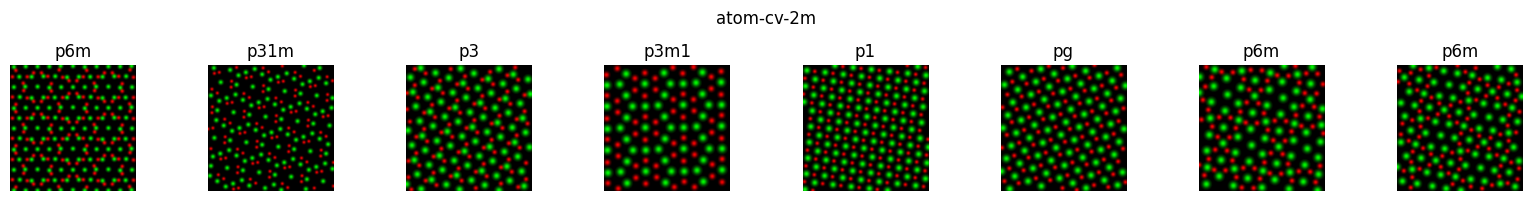

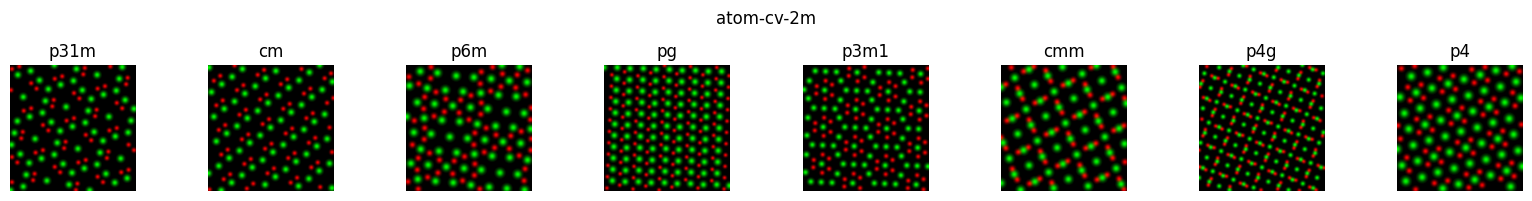

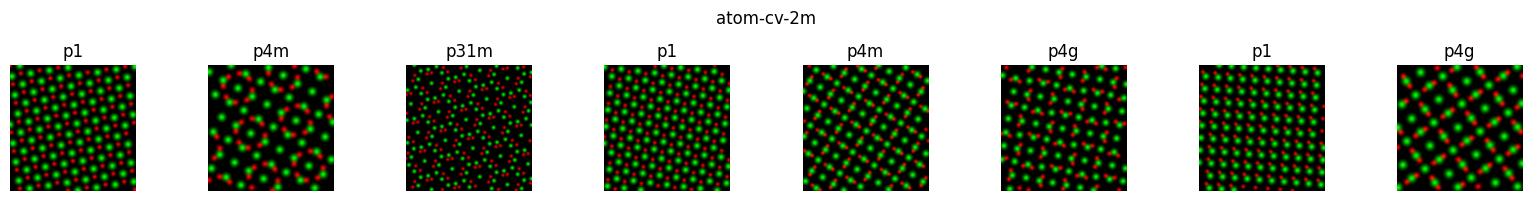

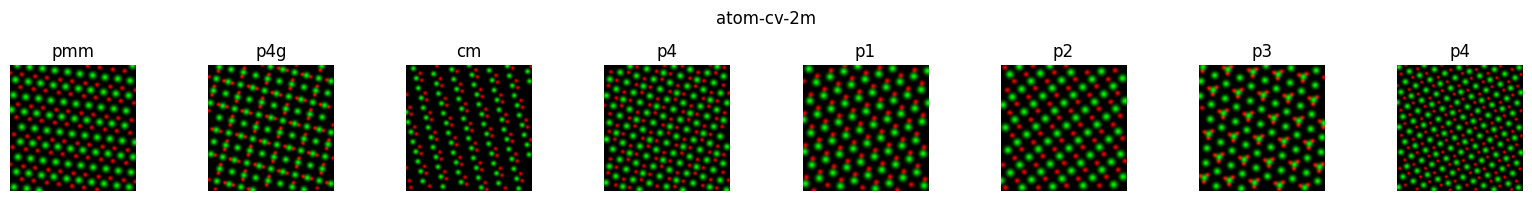

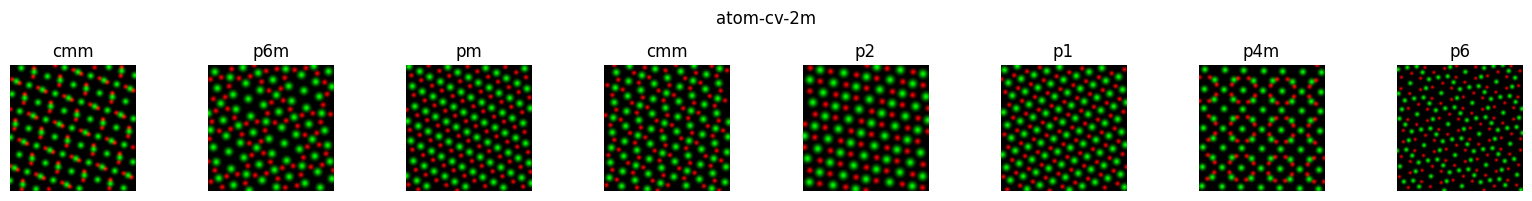

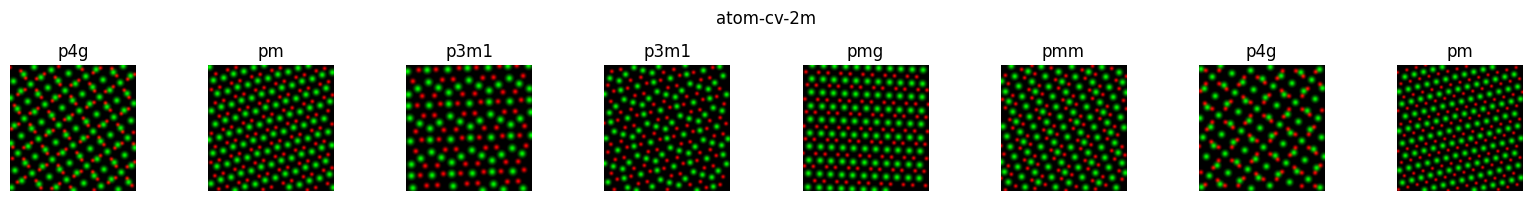

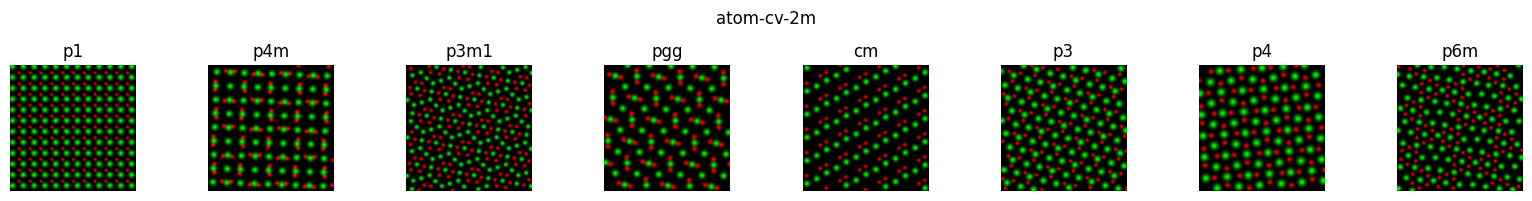

In [24]:
num_workers = 1
batch_size = 32
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom-cv-2m
for file in glob.glob('../../datasets/atom_add_on*'):
    cv_atom_ds_2m = hdf5_dataset(file, folder='test', transform=transforms.ToTensor())
    cv_atom_dl_2m = DataLoader(cv_atom_ds_2m, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    viz_dataloader(cv_atom_dl_2m, label_converter=label_converter, title='atom-cv-2m')

In [7]:
import h5py
import glob
import numpy as np
from tqdm import tqdm 
import random
from Atom_dataset_functions_v4 import wp_atoms
import sys
sys.path.append('../../src/utils/')
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid

In [4]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'r') as h5:
    # labels = h5['test']['labels'][:]
    # VA = h5['test']['translation_uc_vector_a'][:]
    # VB = h5['test']['translation_uc_vector_b'][:]
    print(h5['test']['data'].dtype)

uint8


In [9]:
for file in glob.glob('../../datasets/atom_add_on*.h5'):
    with h5py.File(file, 'r') as h5:
        print(h5['test']['data'].dtype)
        imgs = h5['test']['data'][:5]

uint8
uint8
uint8
uint8
uint8
uint8
uint8


In [10]:
imgs[0]

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [  0, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255,   0],
        [255, 255, 255],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

uint8


In [ ]:
plt.hist(labels, bins=17)

In [10]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


100%|██████████| 238301/238301 [01:18<00:00, 3054.46it/s]

99455


In [11]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on1.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list[:len(h5_new['test']['labels'])])):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

100%|██████████| 17000/17000 [17:35<00:00, 16.10it/s]


In [12]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


100%|██████████| 222301/222301 [01:07<00:00, 3271.31it/s]

82455


In [13]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on3.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list[:len(h5_new['test']['labels'])])):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

100%|██████████| 17000/17000 [19:25<00:00, 14.59it/s]


In [14]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


100%|██████████| 206301/206301 [00:49<00:00, 4191.62it/s]

65455


In [16]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on2.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list[:len(h5_new['test']['labels'])])):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

100%|██████████| 17000/17000 [20:01<00:00, 14.15it/s]


In [17]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


100%|██████████| 190301/190301 [00:19<00:00, 9558.44it/s]

48455


In [18]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on7.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list[:len(h5_new['test']['labels'])])):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

100%|██████████| 17000/17000 [17:32<00:00, 16.15it/s] 


In [28]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


  0%|          | 0/158301 [00:00<?, ?it/s]

100%|██████████| 158301/158301 [00:17<00:00, 9267.80it/s]

14455


In [29]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on4.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list[:len(h5_new['test']['labels'])])):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

100%|██████████| 14455/14455 [12:40<00:00, 19.01it/s]


In [ ]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

In [21]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on5.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list)):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

 54%|█████▍    | 17000/31455 [19:23<16:29, 14.61it/s]


IndexError: Index (17000) out of range for (0-16999)

In [30]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


100%|██████████| 144686/144686 [01:03<00:00, 2261.20it/s]

0


In [26]:
import matplotlib.pyplot as plt

(array([158301., 117145., 117150., 117147., 117148., 117144., 117144.,
        117149., 117144., 117146., 117146., 117144., 117146., 117146.,
        117147., 117147., 117145.]),
 array([ 0.        ,  0.94117647,  1.88235294,  2.82352941,  3.76470588,
         4.70588235,  5.64705882,  6.58823529,  7.52941176,  8.47058824,
         9.41176471, 10.35294118, 11.29411765, 12.23529412, 13.17647059,
        14.11764706, 15.05882353, 16.        ]),
 <BarContainer object of 17 artists>)

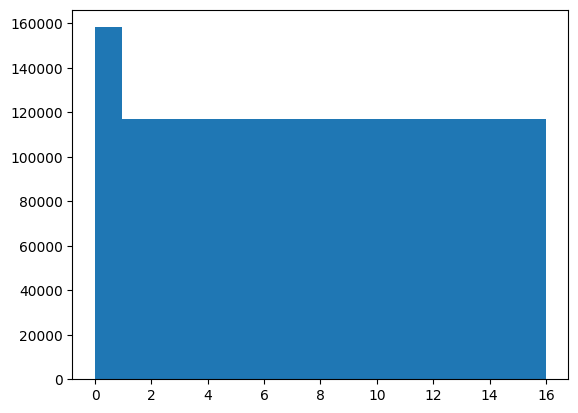

In [27]:
plt.hist(labels, bins=17)

In [9]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list)):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

0it [00:00, ?it/s]

34000it [38:31, 14.71it/s]


IndexError: Index (34000) out of range for (0-33999)

In [ ]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on1.h5', 'r') as h5_new:

        for i_new, i in enumerate(tqdm(blank_list)):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['translation_uc_vector_a'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

In [ ]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

In [5]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
print(len(blank_list))

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:

        for i_new, i in enumerate(tqdm(blank_list[:20000])):
            label = random.choice(symmetry_classes)

            output, unit_cell, metadata = wp_atoms((256,256,3), label, rotation=True)

            h5['test']['data'][i] = output
            h5['test']['unit_cell'][i] = unit_cell
            h5['test']['shapes'][i] = metadata[5, 1]
            h5['test']['translation_start_point'][i] = metadata[0]
            h5['test']['primitive_uc_vector_a'][i] = metadata[1]
            h5['test']['primitive_uc_vector_b'][i] = metadata[2]
            h5['test']['translation_uc_vector_a'][i] = metadata[3]
            h5['test']['translation_uc_vector_b'][i] = metadata[4]

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


  0%|          | 0/270301 [00:00<?, ?it/s]

100%|██████████| 270301/270301 [01:22<00:00, 3269.56it/s]


138474


 25%|██▌       | 5019/20000 [3:32:35<10:34:34,  2.54s/it]


KeyboardInterrupt: 

In [48]:
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    print(h5['test'].keys())

    labels = np.array(h5['test']['labels'])
    indices = np.where(labels == 0)[0]
    blank_list = []

    data = h5['test']['data']
    for i in tqdm(indices):
        if np.sum(data[i]) == 0:
            blank_list.append(i)
len(blank_list)

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
with h5py.File('../../datasets/atom_v4_rot_2m_fixed.h5', 'a') as h5:
    with h5py.File('../../datasets/atom_add_on.h5', 'r') as h5_new:

        for i_new, i in tqdm(enumerate(blank_list)):
            label = random.choice(symmetry_classes)

            h5['test']['data'][i] = np.array(h5_new['test']['data'][i_new])
            h5['test']['labels'][i] = h5_new['test']['labels'][i_new]
            h5['test']['unit_cell'][i] = np.array(h5_new['test']['unit_cell'][i_new])
            h5['test']['shapes'][i] = h5_new['test']['shapes'][i_new]
            h5['test']['translation_start_point'][i] = h5_new['test']['translation_start_point'][i_new]
            h5['test']['primitive_uc_vector_a'][i] = h5_new['test']['primitive_uc_vector_a'][i_new]
            h5['test']['primitive_uc_vector_b'][i] = h5_new['test']['primitive_uc_vector_b'][i_new]
            h5['test']['translation_uc_vector_a'][i] = h5_new['test']['datranslation_uc_vector_ata'][i_new]
            h5['test']['translation_uc_vector_b'][i] = h5_new['test']['translation_uc_vector_b'][i_new]

<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>


  0%|          | 0/270301 [00:00<?, ?it/s]

100%|██████████| 270301/270301 [00:53<00:00, 5035.88it/s] 

160157


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../datasets/atom_add_on.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [30]:
len(blank_list)

160208

In [35]:
len(labels)

2032639

In [36]:
2032639/17

119567.0

In [33]:
blank_labels_list = labels[blank_list]

(array([270351., 110143., 110143., 110143., 110143., 110143., 110143.,
        110143., 110143., 110143., 110143., 110143., 110143., 110143.,
        110143., 110143., 110143.]),
 array([ 0.        ,  0.94117647,  1.88235294,  2.82352941,  3.76470588,
         4.70588235,  5.64705882,  6.58823529,  7.52941176,  8.47058824,
         9.41176471, 10.35294118, 11.29411765, 12.23529412, 13.17647059,
        14.11764706, 15.05882353, 16.        ]),
 <BarContainer object of 17 artists>)

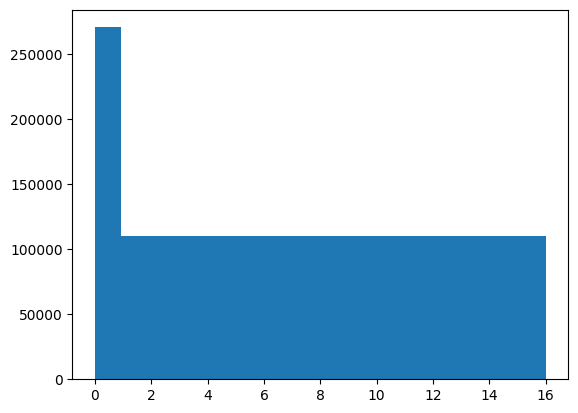

In [38]:
plt.hist(labels, bins=17)

In [22]:
metadata.shape

(6, 2)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


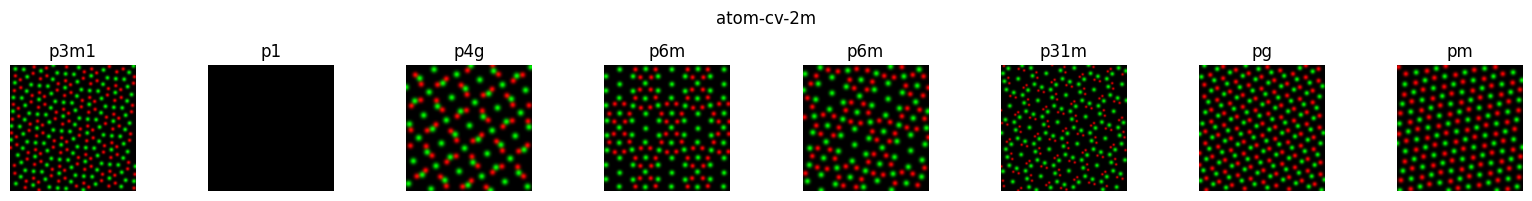

In [27]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import models

import wandb

import sys
sys.path.append('../../src/utils/')
sys.path.append('../../src/benchmark/')
from build_model import resnet50_, resnet34_, densenet161_, fpn_resnet50_classification, xcit_small, xcit_medium
from train_functions import train_epochs, train, valid
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from RotateConvolution import RotateConv2d

# with h5py.File('/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', 'r') as h5:
#     viz_h5_structure(h5)
num_workers = 2
batch_size = 64
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# atom-cv-2m
cv_atom_ds_2m = hdf5_dataset('../../datasets/atom_v4_rot_2m_fixed.h5', folder='test', transform=transforms.ToTensor())
cv_atom_dl_2m = DataLoader(cv_atom_ds_2m, batch_size=32, shuffle=True, num_workers=1)
viz_dataloader(cv_atom_dl_2m, label_converter=label_converter, title='atom-cv-2m')